In [46]:
from pathlib import Path
import contextlib
import math

import numpy as np
import torch
import xarray as xr

from neural_transport.litmodule import NeuralTransport
from neural_transport.datamodule import CarbonDataModule
from neural_transport.tools import conversion

import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import inspect

In [2]:
model = NeuralTransport.load_from_checkpoint("/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250919_dev/singlestep/checkpoints/last.ckpt")

In [3]:
model

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [4]:
# data_kwargs

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=31,
    target_vars=["co2massmix", "airmass"],
    forcing_vars=[
        "gph_bottom",
        "gph_top",
        "p_bottom",
        "p_top",
        "q",
        "t",
        "u",
        "v",
        "blh",
        "cell_area",
        "co2flux_anthro",
        "co2flux_land",
        "co2flux_ocean",
        "orography",
        "tisr",
    ],
    compute=False,
    # time_interval=["1990-01-01", "2014-12-31"],
)

In [5]:
# lit_module_kwargs

from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.models.wrappers_registry import MODELWRAPPERS

TARGET_VARS = ["co2massmix"]
# Uncomment for conditional Flow Matching
FORCING_VARS_1D = [
    # "flow_time"
]
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regulargrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=True,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regulargrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regulargrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

flow = MODELWRAPPERS["flowmatching"](**wrapper_kwargs)

flow.n_samples = 10

lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=10,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [6]:
dset = CarbonDataModule(**data_kwargs)
dset.setup("fit")

In [7]:
dl_val = dset.val_dataloader()
batch_val = next(iter(dl_val[0]))
batch_val = {k: v.squeeze(1) if isinstance(v, torch.Tensor) else v for k, v in batch_val.items()}

In [8]:
model.to(device="cpu")
model.train()

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [9]:
preds = model.model(batch_val)

In [10]:
f"Predictions: Standard Deviation {preds['co2massmix'].std()}, Mean {preds['co2massmix'].mean()}"

'Predictions: Standard Deviation 1.0354238748550415, Mean 0.0015681954100728035'

In [11]:
batch_val["co2massmix_next"].std(), batch_val["co2massmix_next"].mean()

(tensor(8.3530), tensor(614.3007))

In [12]:
batch_normalized = {}
for v in preds:
    for suffix in ['', '_next']:
        key = f"{v}{suffix}"
        if key in batch_val:
            mean = batch_val[f"{v}_offset"]
            std = batch_val[f"{v}_scale"]
            x_in_curr = (batch_val[key] - mean) / std
            batch_normalized[key] = x_in_curr

In [13]:
f'Batch: Standard Deviation: {batch_normalized["co2massmix_next"].std()}, Mean: {batch_normalized["co2massmix_next"].mean()}'

'Batch: Standard Deviation: 0.5031848549842834, Mean: 1.8334089517593384'

In [14]:
model.eval()
model.return_intermediates = True

In [15]:
run_dir = Path.cwd()
ckpt = "best"
massfixer = ["scale"]

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

In [16]:
import importlib
import neural_transport.training.train as train
importlib.reload(train)

train.predict(
        run_dir / "singlestep",
        data_path_forecast,
        data_kwargs,
        device="cuda",
        freq=freq,
        ckpt=ckpt,
        lit_module_kwargs=lit_module_kwargs,
        massfixer=massfixer,
    )

Generating /Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250919_dev/singlestep/checkpoints/Epoch=23-Step=9312-LossVal=0.087359.ckpt best CKPT
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMap

In [17]:
target_path = (
        data_path_forecast
        / f"{data_kwargs['dataset']}_{data_kwargs['grid']}_{data_kwargs['vertical_levels']}_{data_kwargs['freq']}.zarr"
    )

pred_path = (
        run_dir
        / "singlestep"
        / "preds"
        / f"ckpt={ckpt}_massfixer={massfixer}"
        / f"co2_pred_rollout_{freq}.zarr"
    )

In [18]:
samples = xr.open_zarr("/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250919_dev/singlestep/preds/ckpt=best_massfixer=default/co2_pred_rollout_QS.zarr")

In [19]:
samples

<xarray.Dataset> Size: 90MB
Dimensions:     (lat: 32, sample: 100, lon: 64, level: 10, time: 10)
Coordinates:
  * lat         (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * level       (level) float64 80B 1.013e+03 1.005e+03 995.0 ... 243.0 73.0
  * time        (time) datetime64[ns] 80B 2018-01-01 ... 2018-01-03T06:00:00
  * sample      (sample) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
  * lon         (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    co2massmix  (sample, lat, lon, level) float32 8MB dask.array<chunksize=(50, 16, 32, 5), meta=np.ndarray>
    trajectory  (sample, time, lat, lon, level) float32 82MB dask.array<chunksize=(25, 5, 16, 32, 5), meta=np.ndarray>

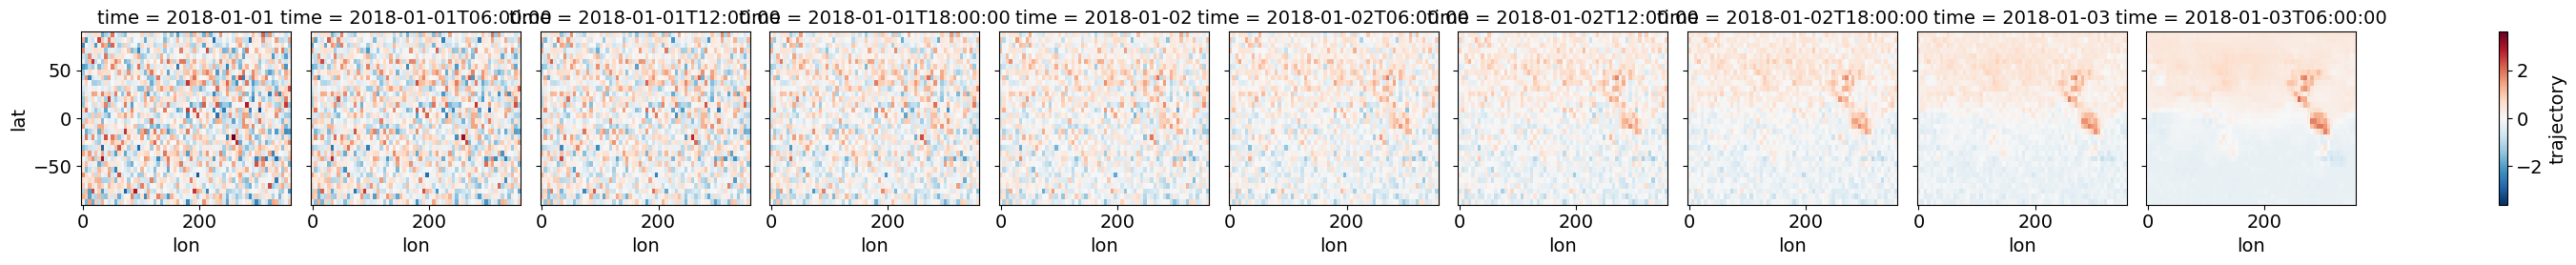

In [73]:
samples.trajectory.isel(sample=0, level=0).plot(col="time")
plt.show()

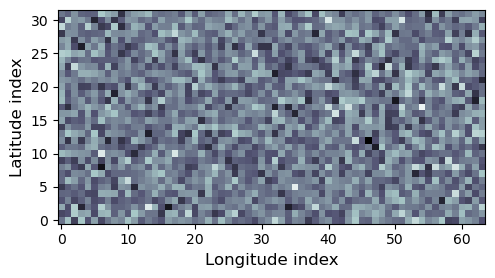

In [48]:
def plot_sample_as_indices(ds, sample_idx=0, level_idx=0, time_idx=9):
    """
    Plot one trajectory slice using array indices (0..N-1) instead of lat/lon degrees.
    """

    da = ds["trajectory"].isel(sample=sample_idx, time=time_idx, level=level_idx)

    # Create a copy with replaced coordinates
    da_idx = da.copy()
    da_idx = da_idx.assign_coords(
        lat=range(da_idx.sizes["lat"]),
        lon=range(da_idx.sizes["lon"]),
    )

    fig, ax = plt.subplots(figsize=(6, 3))
    da_idx.plot(ax=ax, add_colorbar=False, cmap="bone_r")
    ax.set_aspect("equal")
    ax.set_xlabel("Longitude index", fontsize=12)
    ax.set_ylabel("Latitude index", fontsize=12)
    ax.set_xticks(np.arange(7) * 10)  # optional: choose nice tick spacing
    ax.set_yticks([0, 5, 10, 15, 20, 25, 30])
    ax.tick_params(labelsize=10)
    ax.set_title("")
    plt.tight_layout()
    plt.show()

# Example usage
plot_sample_as_indices(samples, sample_idx=0, time_idx=0, level_idx=0)

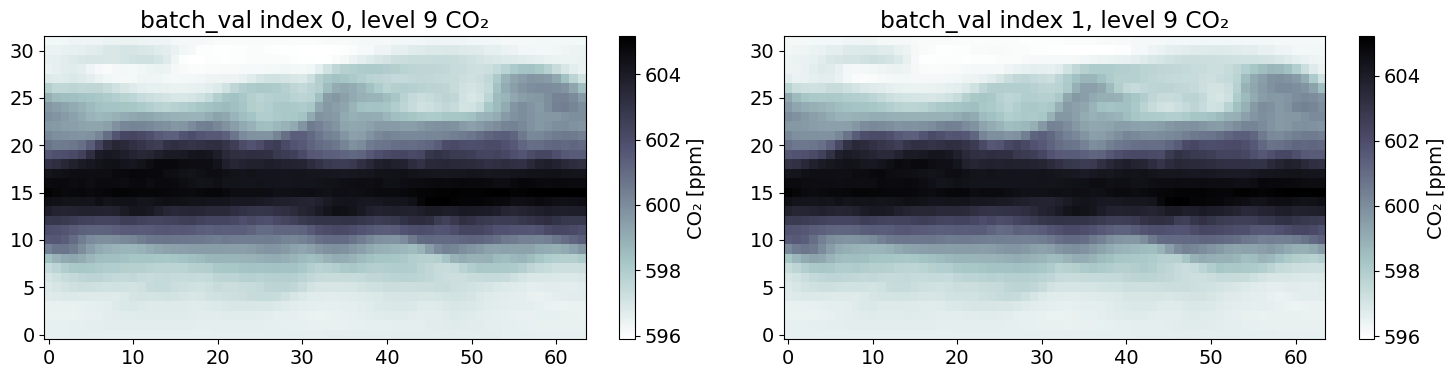

In [49]:
B, N, C = batch_val["co2massmix"].shape
lat, lon = 32, 64

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, ax in enumerate(axes):
    data = batch_val["co2massmix"][i, :, 9].cpu().numpy().reshape(lat, lon)

    im = ax.imshow(data, origin="lower", cmap="bone_r", aspect="auto")
    ax.set_title(f"batch_val index {i}, level 9 CO₂")

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("CO₂ [ppm]")

plt.tight_layout()
plt.savefig("batch_val_level_9_co2.png", dpi=300)
plt.show()

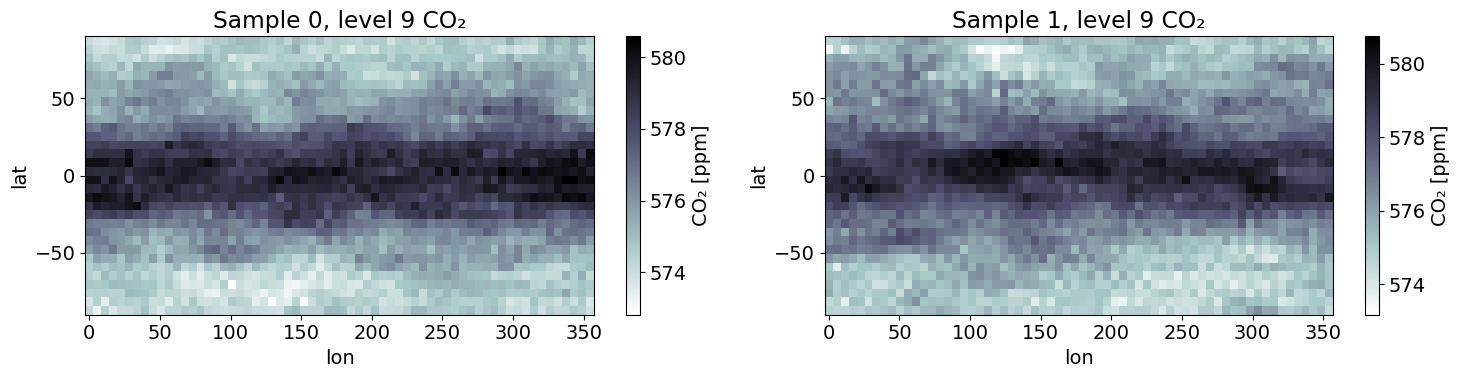

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, ax in enumerate(axes):
    da = samples["co2massmix"].isel(sample=i, level=9).compute()
    da.plot(
        x="lon", y="lat", ax=ax, cmap="bone_r",
        cbar_kwargs={"label": "CO₂ [ppm]"},
    )
    ax.set_title(f"Sample {i}, level 9 CO₂")

plt.tight_layout()
plt.savefig("samples_level_9_co2.png", dpi=300)
plt.show()

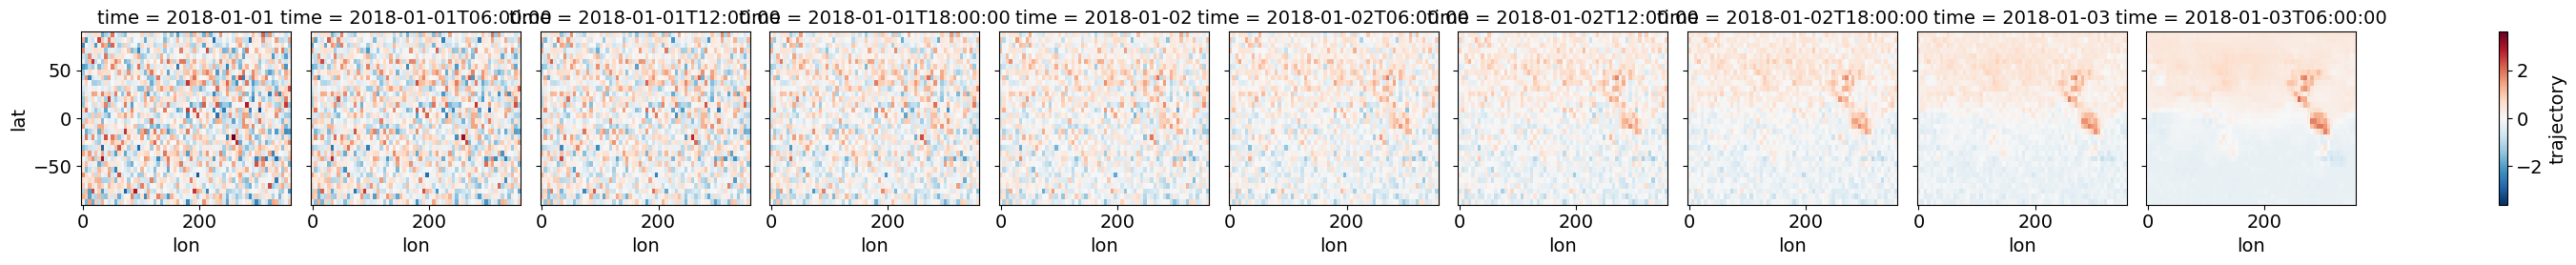

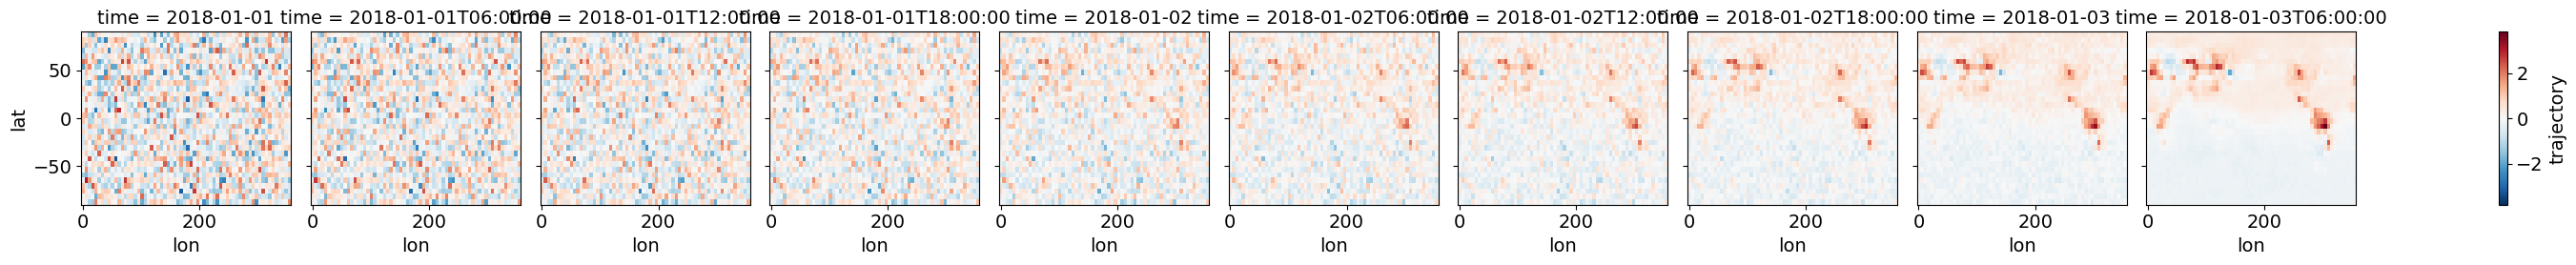

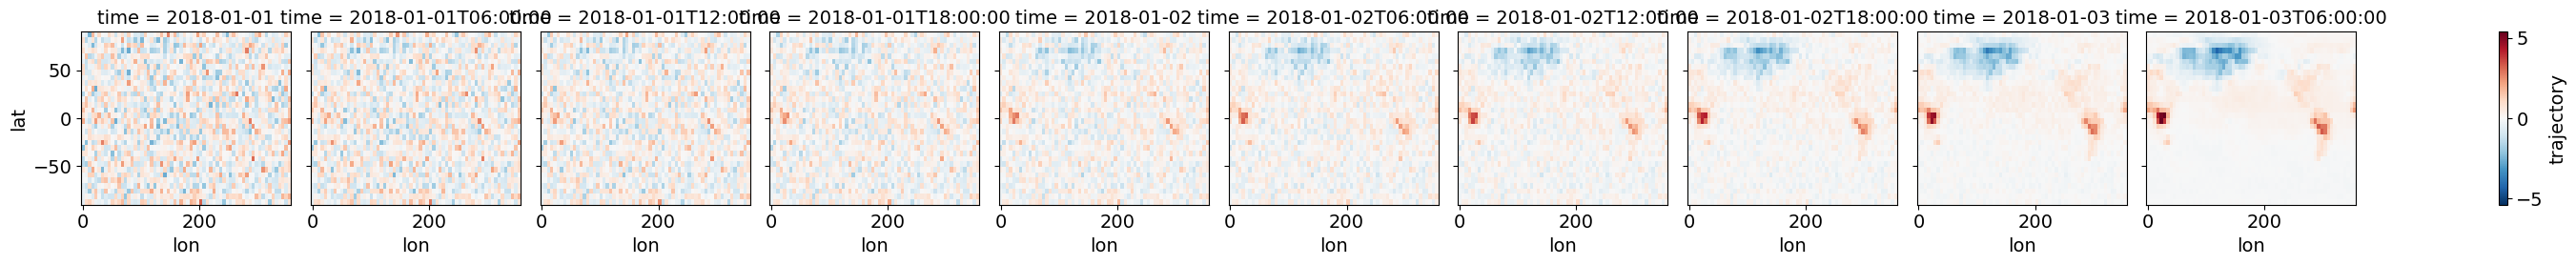

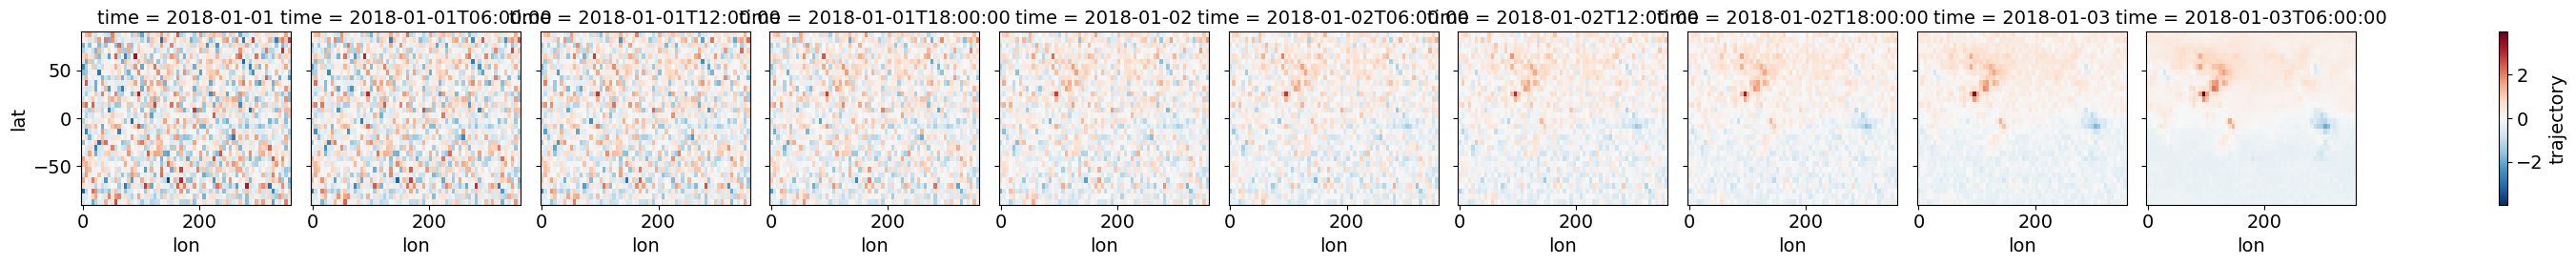

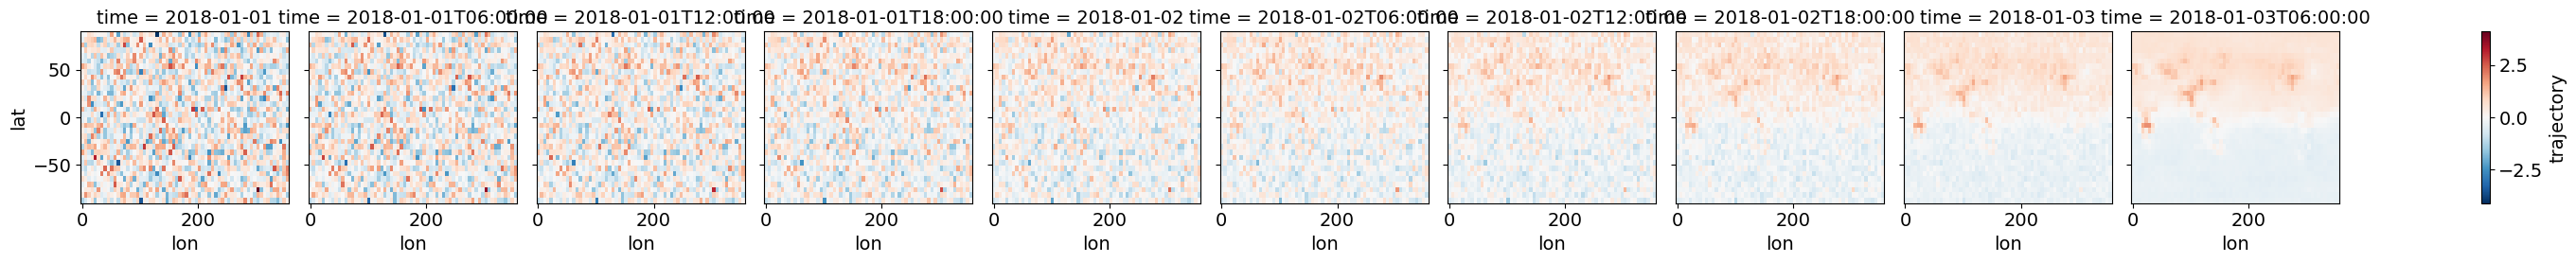

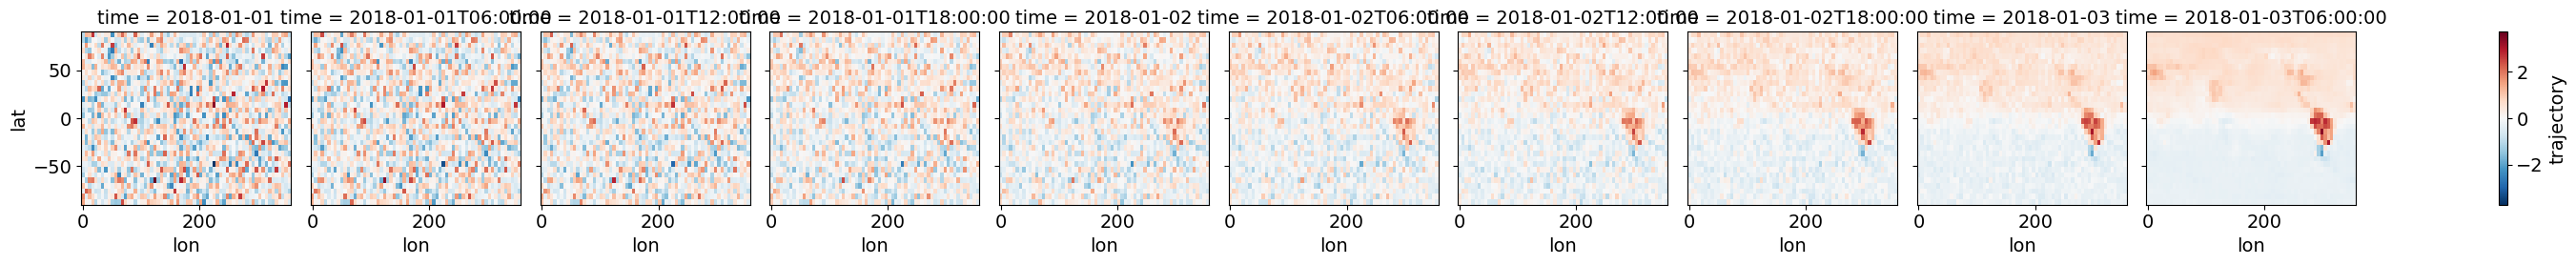

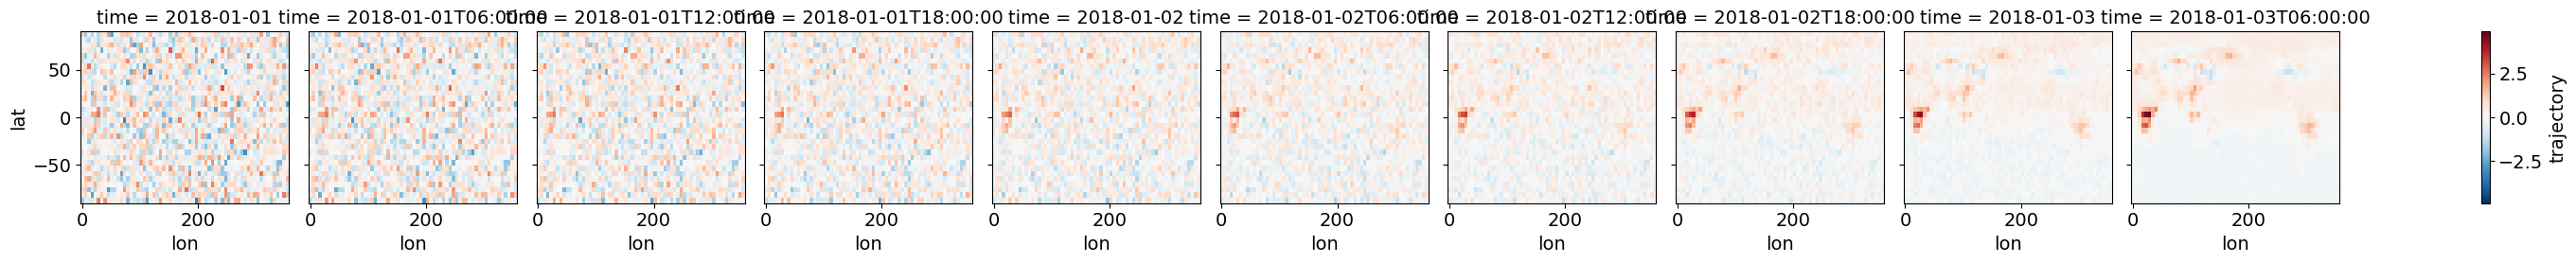

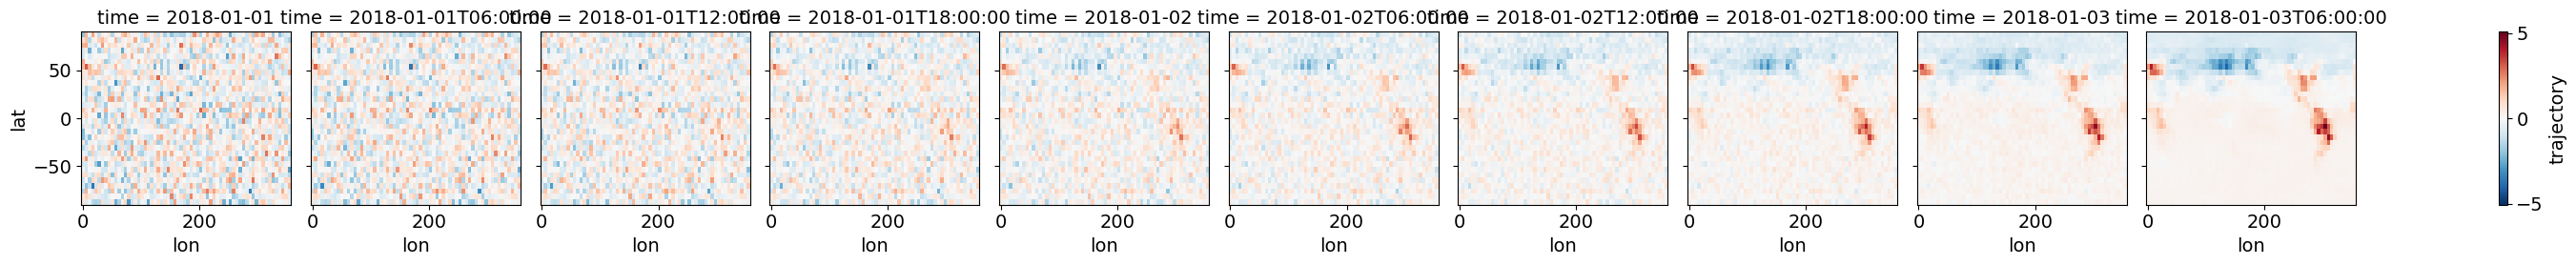

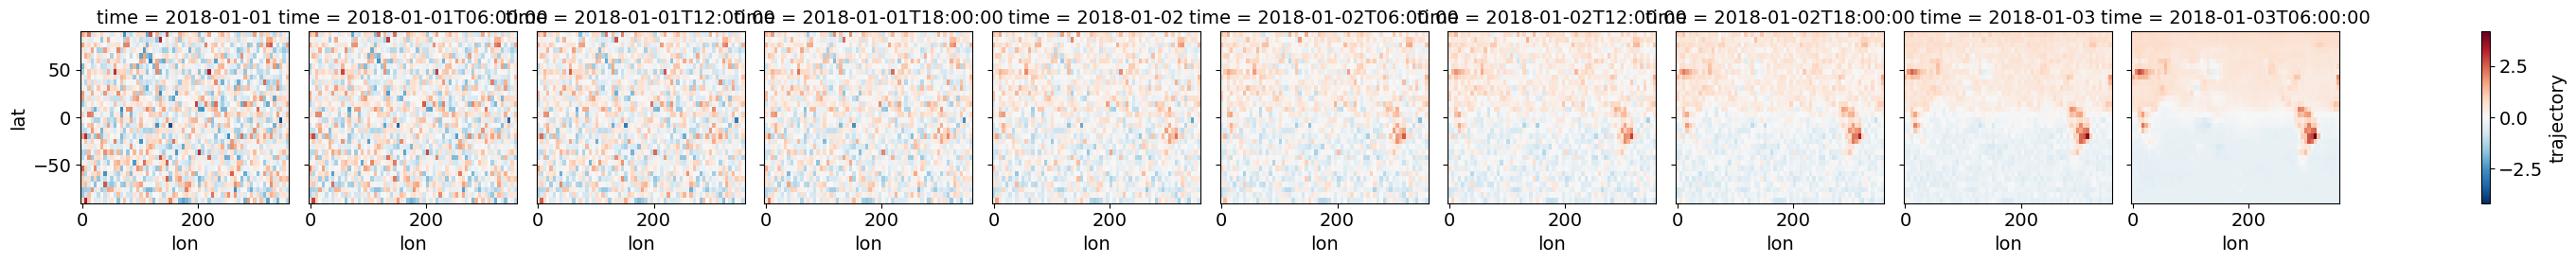

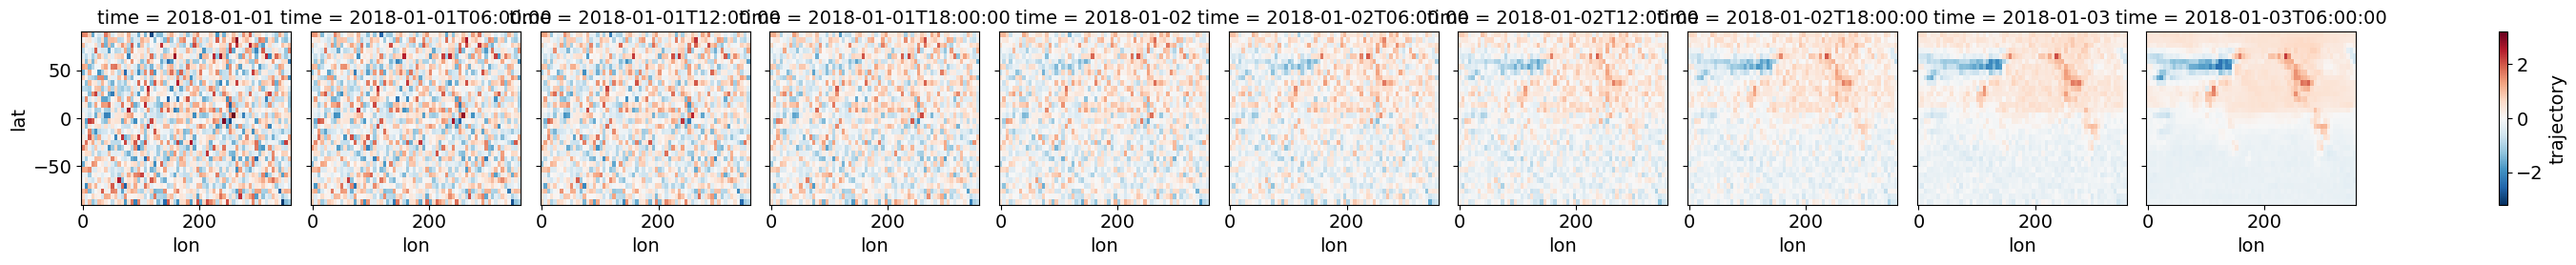

In [51]:
for i in range(10):
    samples.trajectory.isel(sample=i, level=0).plot(col="time")
plt.show()

# Plots

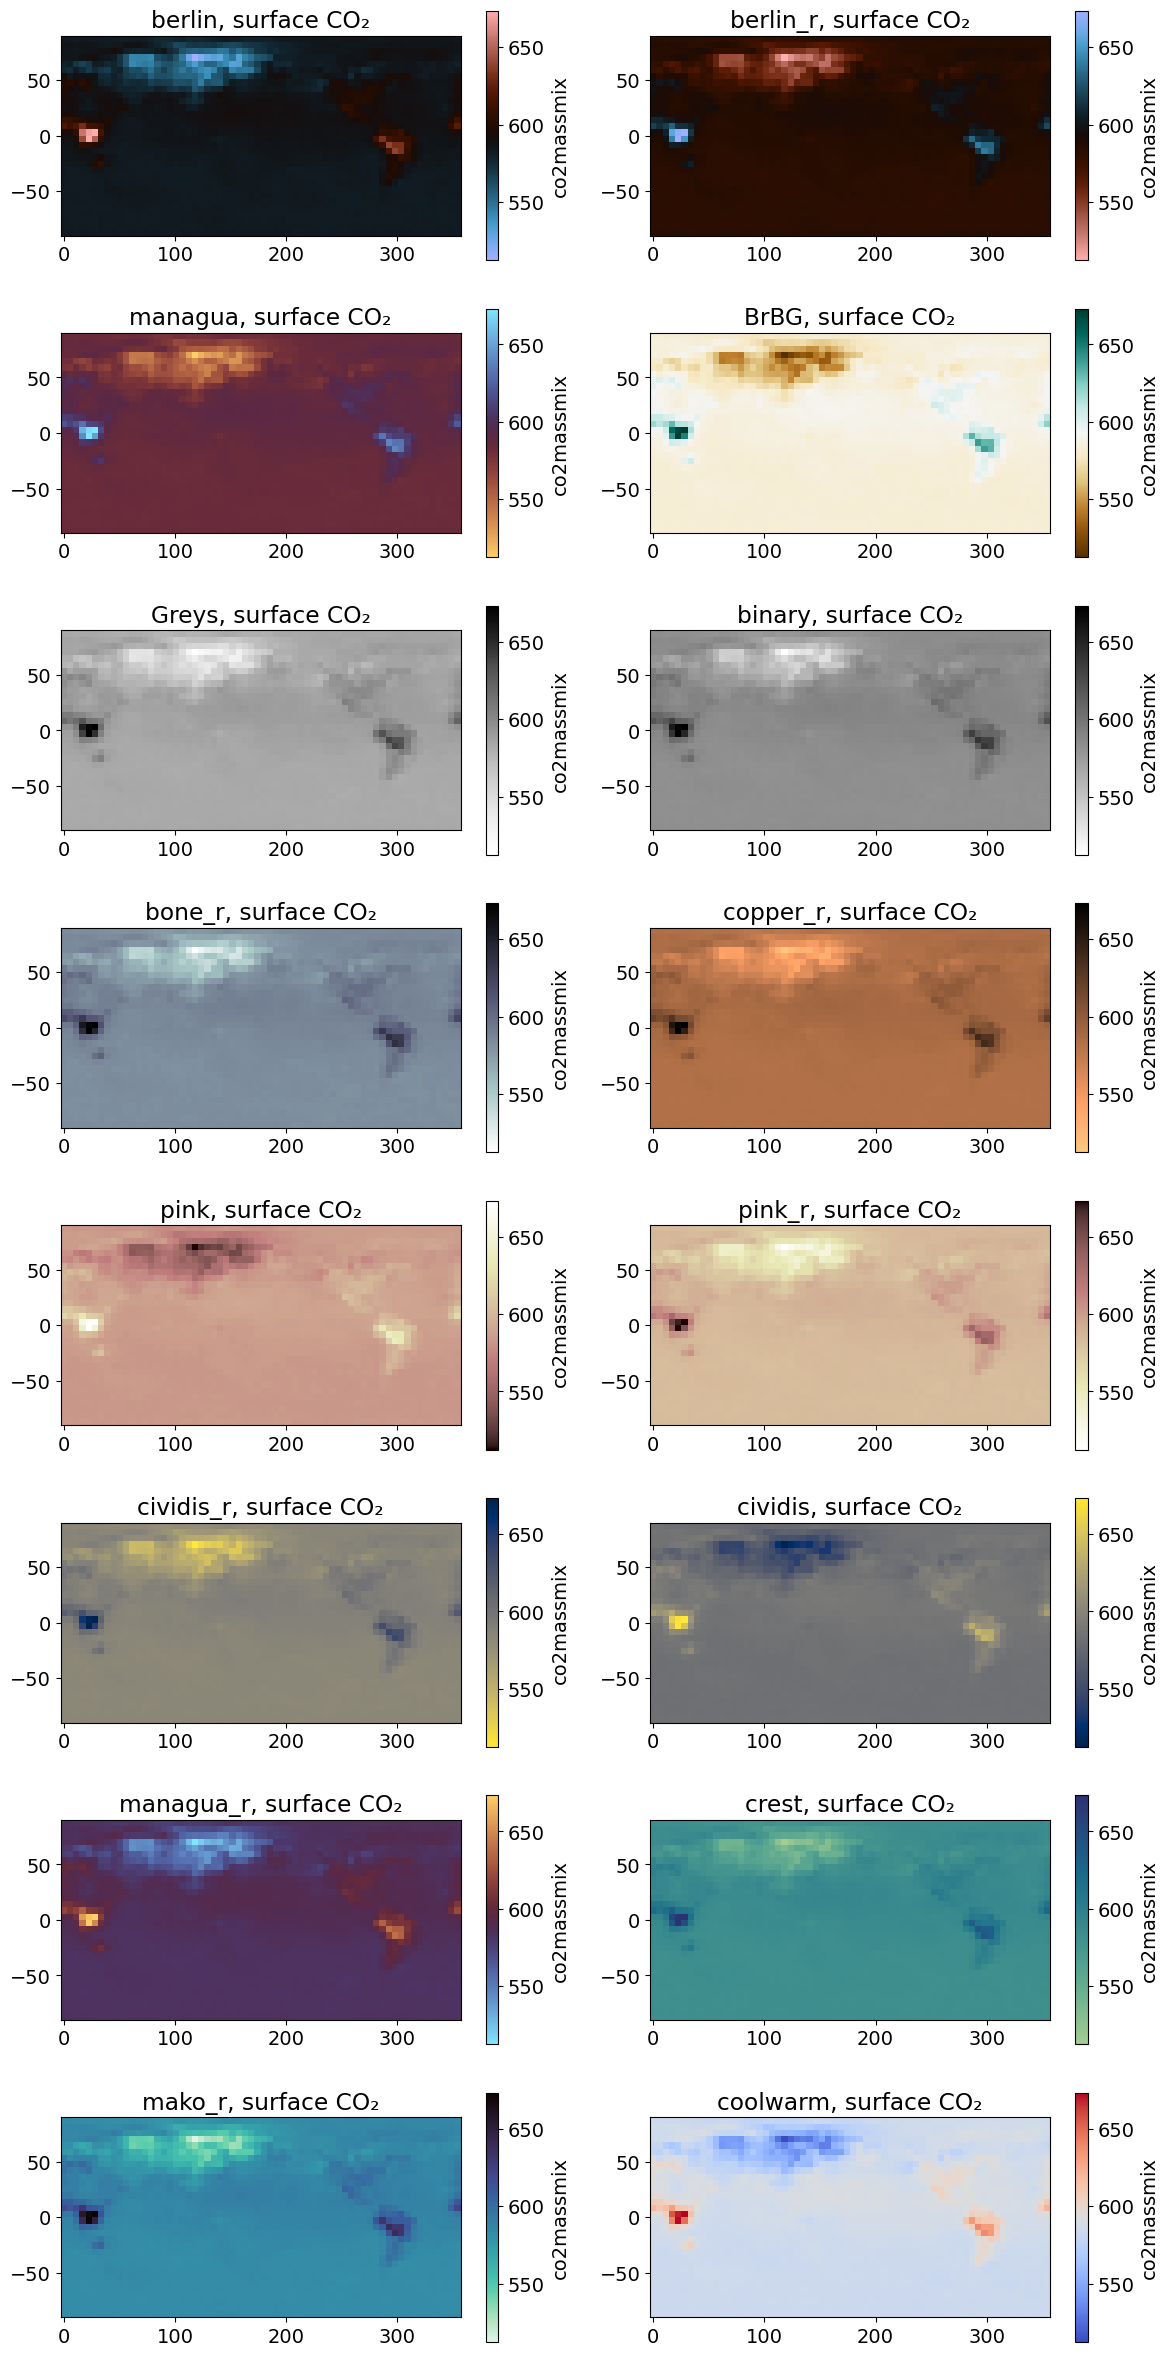

In [52]:
cmap_selected = [
    "berlin", "berlin_r", "managua", "BrBG", "Greys", "binary", "bone_r", "copper_r", "pink", "pink_r", "cividis_r", "cividis", "managua_r", "crest", "mako_r", "coolwarm"
]
cmap = ["copper_r", "bone_r", "binary"]

def plot_cmaps(cmap, n_col=2):
    n_colors = len(cmap)
    n_col = n_col
    n_rows = math.ceil(n_colors / n_col)

    fig, axes = plt.subplots(n_rows, n_col, figsize=(12, 3 * n_rows))
    axes = axes.ravel()

    da = samples["co2massmix"].isel(sample=2, level=0).compute()

    for i, ax in enumerate(axes):
        if i < n_colors:
            da.plot(x="lon", y="lat", ax=ax, cmap=cmap[i])
            ax.set_aspect("equal")
            ax.set_title(f"{cmap[i]}, surface CO₂")
            ax.set_xlabel("")
            ax.set_ylabel("")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_cmaps(cmap_selected)

In [53]:
# cmap_large = [
#     # Perceptually uniform sequential
#     "viridis", "plasma", "inferno", "magma", "cividis", "turbo",
#     # Cyclic
#     "twilight", "twilight_shifted",
#     # Sequential (single-hue)
#     "Blues", "BuGn", "BuPu", "GnBu", "Greens", "Greys", "OrRd", "Oranges", "PuBu", "PuBuGn",
#     "PuRd", "Purples", "Reds", "YlGn", "YlGnBu", "YlOrBr", "YlOrRd",
#     # Diverging
#     "BrBG", "PiYG", "PRGn", "PuOr", "RdBu", "RdGy", "RdYlBu",
#     "RdYlGn", "Spectral", "coolwarm", "bwr", "seismic",
#     # Miscellaneous / qualitative
#     "Accent", "Dark2", "Paired", "Pastel1", "Pastel2",
#     "Set1", "Set2", "Set3", "tab10", "tab20", "tab20b", "tab20c",
#     # Miscellaneous continuous
#     "CMRmap", "cubehelix", "gist_earth", "gist_gray", "gist_heat",
#     "gist_ncar", "gist_rainbow", "gist_stern", "gist_yarg",
#     "gnuplot", "gnuplot2", "ocean", "pink", "terrain", "nipy_spectral",
#     "afmhot", "autumn", "binary", "bone", "brg", "cool", "copper",
#     "flag", "gray", "hot", "hsv", "jet", "prism", "rainbow",
#     "spring", "summer", "winter", "Wistia",
# ]

# # Optionally include reversed versions:
# cmap_large_reversed = cmap_large + [c + "_r" for c in cmap_large]

# plot_cmaps(plt.colormaps(), n_col=2)

In [121]:
def plot_trajectories(
    da_traj,
    n_samples=2,
    different_samples=True,
    sample_indices=None,
    level_idx=0,
    time_indices=None,
    cmaps=None,
    seed=42,
    figsize=None,
    show=True,
    title="Sample Trajectories",
    savefig=False,
    filename="trajectories.png",
):
    """
    Plot trajectories for selected/random samples.

    Parameters
    ----------
    da_traj : xarray.DataArray
        Must have dims: sample, time, level, lat, lon.
    n_samples : int
        Number of random samples to choose (ignored if sample_indices is provided).
    sample_indices : sequence[int] or None
        If provided, use these sample indices instead of random choice.
    level_idx : int
        Level index to select.
    time_indices : list[int] or None
        Time indices to plot; default = [0, ..., 9].
    cmaps : list[str] or None
        List of colormap names, one per sample (row).
        If None, use ["viridis"] for all rows.
    seed : int
        RNG seed for reproducibility.
    figsize : tuple or None
        Figure size. If None, computed automatically.
    show : bool
        If True, calls plt.show().
    savefig : bool
        If True, saves figure to `filename`.
    filename : str
        Path to save figure.
    """
    if "sample" not in da_traj.dims:
        raise ValueError("da_traj must have a 'sample' dimension")
    if "time" not in da_traj.dims:
        raise ValueError("da_traj must have a 'time' dimension")
    if "lat" not in da_traj.dims or "lon" not in da_traj.dims:
        raise ValueError("da_traj must have 'lat' and 'lon' dims for plotting")

    if time_indices is None:
        time_indices = list(range(10))

    # choose sample indices
    if different_samples:
        if sample_indices is not None:
            sample_indices = list(sample_indices)[:n_samples]
            if len(sample_indices) < n_samples:
                raise ValueError("sample_indices shorter than n_samples")
        else:
            rng = np.random.default_rng(seed)
            n_available = da_traj.sizes["sample"]
            if n_samples > n_available:
                raise ValueError("n_samples > available samples")
            sample_indices = list(rng.choice(n_available, size=n_samples, replace=False))
    else:
        sample_indices = [64] * n_samples

    # Build figure and axes
    nrow = len(sample_indices)
    ncol = len(time_indices)

    if cmaps is None:
        cmaps = ["viridis"] * nrow
    elif len(cmaps) < nrow:
        cmaps = cmaps + ["viridis"] * (nrow - len(cmaps))

    # Infer aspect ratio
    aspect = da_traj.sizes["lat"] / da_traj.sizes["lon"]
    panel_width = 3.0
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol, (panel_height + 0.5) * nrow)

    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, squeeze=False)

    last_maps = []

    for i, (sample_idx, cmap) in enumerate(zip(sample_indices, cmaps)):
        da_sample = da_traj.isel(sample=sample_idx, level=level_idx)

        # ensure it's loaded (safe for dask-backed arrays)
        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        for j, time_idx in enumerate(time_indices):
            ax = axes[i, j]
            da_slice = da_sample.isel(time=time_idx)

            mappable = da_slice.plot(ax=ax, cmap=cmap, add_colorbar=False, add_labels=False)

            ax.set_aspect('equal', adjustable='box')
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_xticks([0, 120, 240])
            ax.set_yticks([-45, 0, 45])

            if j > 0:
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_xticklabels([])
                ax.set_yticklabels([])

            ax.text(
                0.05, 0.93, f"t={time_idx}",
                transform=ax.transAxes,
                fontsize=10,
                fontweight="bold",
                color="white",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.5),
            )
        last_maps.append(mappable)

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])

    for i, (sample_idx, mappable) in enumerate(zip(sample_indices, last_maps)):
        row_axes = axes[i, :]
        row_bottom = row_axes[0].get_position().y0
        row_top = row_axes[-1].get_position().y1
        row_height = row_top - row_bottom

        cbar_ax = fig.add_axes([
            0.92, # x-position
            row_bottom, # y-position at bottom of row
            0.007, # width
            row_height # height of row
        ])
        fig.colorbar(mappable, cax=cbar_ax, label="CO₂")

        # fig.text(
        #     0.5, row_top + 0.005,
        #     f"Sample {sample_idx}",
        #     ha="center", va="bottom",
        #     fontsize=12, fontweight="bold",
        #     transform=fig.transFigure
        # )

    if title:
        fig.suptitle(title, fontsize=20, fontweight="bold")

    if savefig:
        fig.savefig(filename, dpi=300)
    if show:
        plt.show()

    return fig, axes


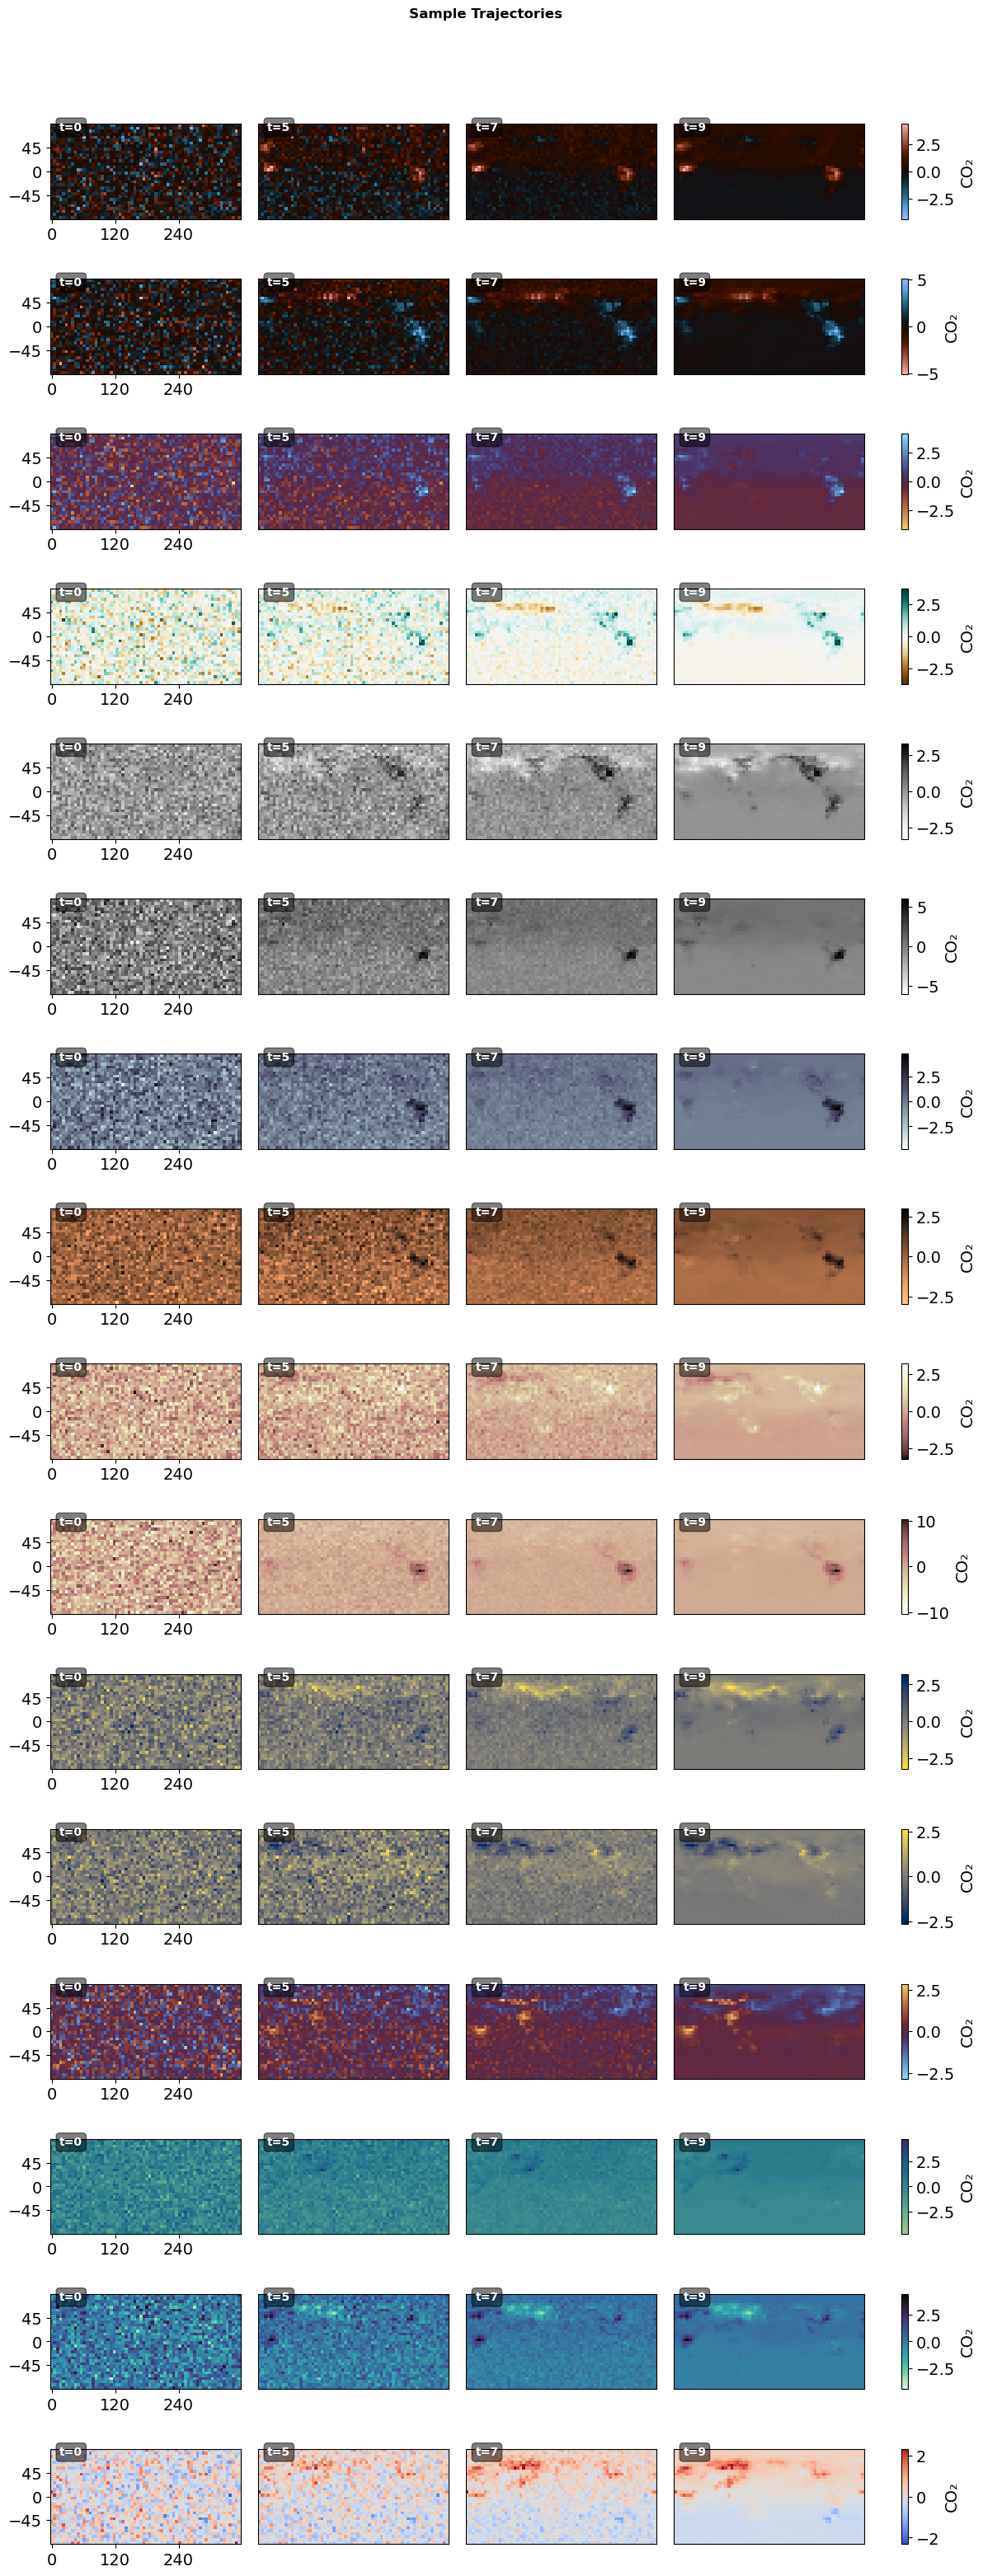

In [55]:
plot_trajectories(
    samples.trajectory,
    n_samples=len(cmap_selected),
    sample_indices=None,
    level_idx=0,
    time_indices=[0, 5, 7, 9],
    cmaps=cmap_selected,
    seed=42,
    figsize=None,
    show=True,
    savefig=False,
    filename="trajectories.png",
);

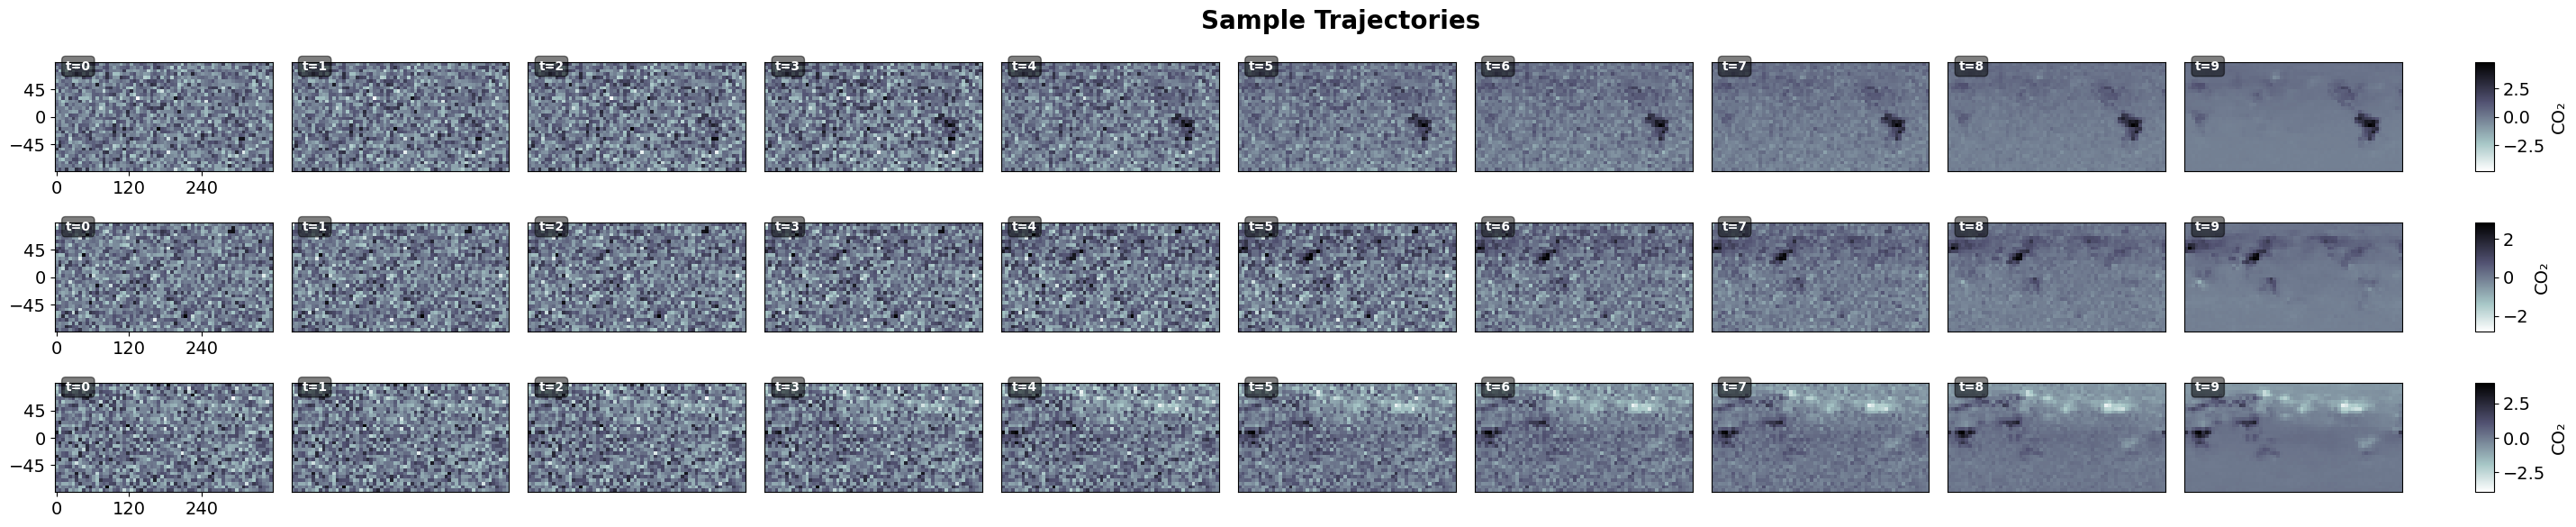

In [122]:
plot_trajectories(
    samples.trajectory,
    n_samples=3,
    sample_indices=None,
    different_samples=True,
    level_idx=0,
    cmaps=["bone_r"]*3,
    seed=1,
    figsize=None,
    show=True,
    savefig=True,
    title="Sample Trajectories",
    filename="trajectory_bone_r_selected.png",
);

In [57]:
def plot_samples(
    da_traj,
    n_samples=2,
    ncol=2,
    sample_indices=None,
    level_idx=0,
    cmaps=None,
    seed=42,
    figsize=None,
    show=True,
    savefig=False,
    filename="samples.png",
):
    """
    Plot selected/random samples at the last time step.

    Parameters
    ----------
    da_traj : xarray.DataArray
        Must have dims: sample, time, level, lat, lon.
    n_samples : int
        Number of random samples to choose (ignored if sample_indices is provided).
    ncol : int
        Number of columns in subplot grid.
    sample_indices : sequence[int] or None
        If provided, use these sample indices instead of random choice.
    level_idx : int
        Level index to select.
    cmaps : list[str] or None
        List of colormap names, one per sample.
        If None, use ["viridis"] for all samples.
    seed : int
        RNG seed for reproducibility.
    figsize : tuple or None
        Figure size. If None, computed automatically.
    show : bool
        If True, calls plt.show().
    savefig : bool
        If True, saves figure to `filename`.
    filename : str
        Path to save figure.
    """
    if "sample" not in da_traj.dims:
        raise ValueError("da_traj must have a 'sample' dimension")
    if "time" not in da_traj.dims:
        raise ValueError("da_traj must have a 'time' dimension")
    if "lat" not in da_traj.dims or "lon" not in da_traj.dims:
        raise ValueError("da_traj must have 'lat' and 'lon' dims for plotting")

    # Choose sample indices
    if sample_indices is not None:
        sample_indices = list(sample_indices)[:n_samples]
        if len(sample_indices) < n_samples:
            raise ValueError("sample_indices shorter than n_samples")
    else:
        rng = np.random.default_rng(seed)
        n_available = da_traj.sizes["sample"]
        if n_samples > n_available:
            raise ValueError("n_samples > available samples")
        sample_indices = list(rng.choice(n_available, size=n_samples, replace=False))

    # Setup colormaps
    if cmaps is None:
        cmaps = ["viridis"] * n_samples
    elif len(cmaps) < n_samples:
        cmaps = cmaps + ["viridis"] * (n_samples - len(cmaps))

    # Last time step
    last_time = da_traj.sizes["time"] - 1

    # Grid dimensions
    nrow = int(np.ceil(n_samples / ncol))

    # Aspect ratio and figure size
    aspect = da_traj.sizes["lat"] / da_traj.sizes["lon"]
    panel_width = 6.0
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol, (panel_height + 0.6) * nrow)

    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, squeeze=False)

    # Flatten axes for easy iteration
    axes_flat = axes.ravel()

    for i, (sample_idx, cmap) in enumerate(zip(sample_indices, cmaps)):
        ax = axes_flat[i]

        da_sample = da_traj.isel(sample=sample_idx, level=level_idx, time=last_time)
        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        # Plot single panel
        mapable = da_sample.plot(ax=ax, cmap=cmap, add_colorbar=False, add_labels=False)

        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f"Sample {sample_idx}", fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")

        # Individual colorbar for each subplot
        cbar = fig.colorbar(mapable, ax=ax, fraction=0.025, pad=0.04)
        cbar.ax.set_ylabel("XCO₂ [ppm]", rotation=270, labelpad=15)

    # Hide unused axes (if n_samples not multiple of ncol)
    for j in range(len(sample_indices), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    if savefig:
        fig.savefig(filename, dpi=300)
    if show:
        plt.show()

    # return fig, axes

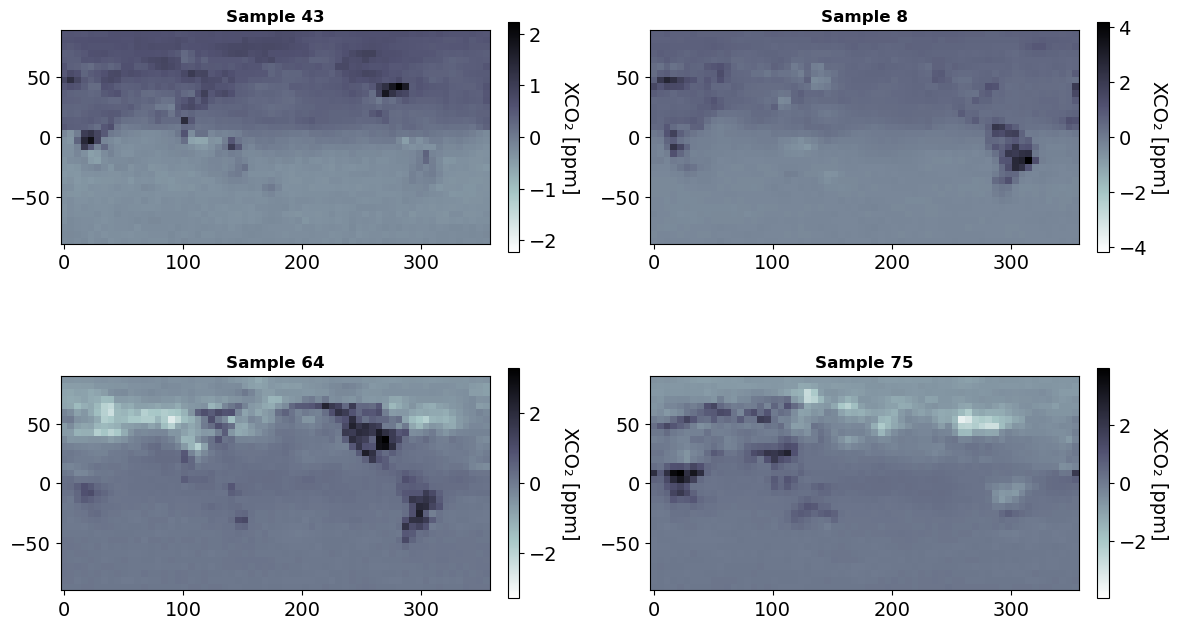

In [58]:
plot_samples(
    samples.trajectory,
    n_samples=4,
    ncol=2,
    sample_indices=None,
    level_idx=0,
    cmaps=["bone_r"]*4,
    seed=42,
    figsize=None,
    show=True,
    savefig=True,
    filename="samples.png",
)

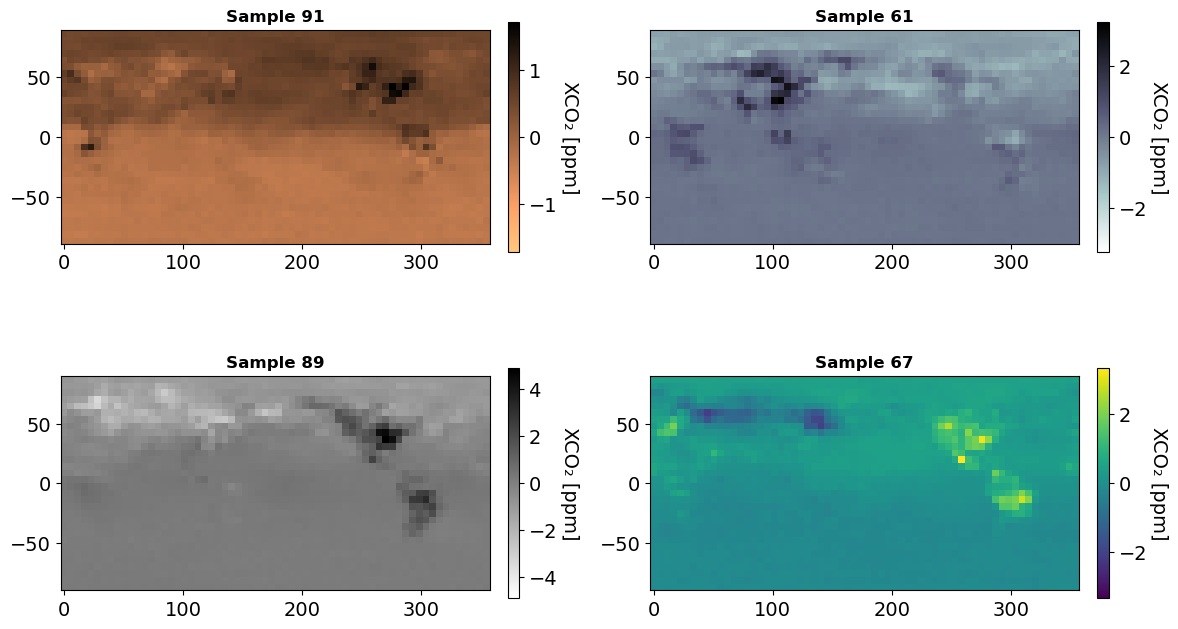

In [59]:
plot_samples(
    samples.trajectory,
    n_samples=4,
    ncol=2,
    sample_indices=None,
    level_idx=0,
    cmaps=cmap,
    seed=7,
    figsize=None,
    show=True,
    savefig=True,
    filename="samples.png",
)

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import contextlib
import cartopy.feature as cfeature

def decorate_earth(ax,
                   terrain=False,
                   grid=False,
                   land=False, ocean=False,
                   borders=False, lakes=False, rivers=False):
    """Add optional geographic features to an axis."""
    ax.coastlines()

    if grid:
        gl = ax.gridlines(
            draw_labels=True, linewidth=0.5, color="dimgray",
            alpha=0.4, zorder=2
        )
        gl.xlabel_style = {"size": 8, "color": "dimgray"}
        gl.ylabel_style = {"size": 8, "color": "dimgray"}
        gl.bottom_labels = False
        gl.right_labels = False

    if terrain:
        ax.stock_img()
    if land:
        ax.add_feature(cfeature.LAND)
    if ocean:
        ax.add_feature(cfeature.OCEAN)
    if borders:
        ax.add_feature(cfeature.BORDERS, linestyle=':')
    if lakes:
        ax.add_feature(cfeature.LAKES)
    if rivers:
        ax.add_feature(cfeature.RIVERS)

def plot_samples_projection(
    da_traj,
    projection=None,
    terrain=False,
    grid=False,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=2,
    ncol=2,
    sample_indices=None,
    level_idx=0,
    cmaps=None,
    seed=42,
    figsize=None,
    show=True,
    savefig=False,
    filename="samples.png",
):
    """Plot selected/random samples at the last time step on a global projection."""
    if "sample" not in da_traj.dims:
        raise ValueError("da_traj must have a 'sample' dimension")
    if "time" not in da_traj.dims:
        raise ValueError("da_traj must have a 'time' dimension")
    if "lat" not in da_traj.dims or "lon" not in da_traj.dims:
        raise ValueError("da_traj must have 'lat' and 'lon' dims for plotting")

    # Choose sample indices
    if sample_indices is not None:
        sample_indices = list(sample_indices)[:n_samples]
        if len(sample_indices) < n_samples:
            raise ValueError("sample_indices shorter than n_samples")
    else:
        rng = np.random.default_rng(seed)
        n_available = da_traj.sizes["sample"]
        if n_samples > n_available:
            raise ValueError("n_samples > available samples")
        sample_indices = list(rng.choice(n_available, size=n_samples, replace=False))

    # Setup colormaps
    if cmaps is None:
        cmaps = ["viridis"] * n_samples
    elif len(cmaps) < n_samples:
        cmaps = cmaps + ["viridis"] * (n_samples - len(cmaps))

    # Setup projections
    if projection is None:
        projections = [ccrs.PlateCarree()] * n_samples
    elif isinstance(projection, list):
        if len(projection) < n_samples:
            projections = projection + [projection[-1]] * (n_samples - len(projection))
        else:
            projections = projection[:n_samples]
    else:
        projections = [projection] * n_samples

    # Last time step
    last_time = da_traj.sizes["time"] - 1

    # Grid setup
    nrow = int(np.ceil(n_samples / ncol))
    aspect = da_traj.sizes["lat"] / da_traj.sizes["lon"]
    panel_width = 8.0
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol, (panel_height + 0.6) * nrow)

    # Figure and axes
    fig, axes = plt.subplots(
        nrow, ncol,
        figsize=figsize,
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False
    )
    axes_flat = axes.ravel()

    for i, (sample_idx, cmap, proj) in enumerate(zip(sample_indices, cmaps, projections)):
        ax = fig.add_subplot(axes_flat[i].get_subplotspec(), projection=proj)
        axes_flat[i].remove()  # remove placeholder

        da_sample = da_traj.isel(sample=sample_idx, level=level_idx, time=last_time)
        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        decorate_earth(
            ax,
            terrain=terrain,
            grid=grid,
            land=land, ocean=ocean, borders=borders, lakes=lakes, rivers=rivers
        )
        mapable = da_sample.plot(
            ax=ax, cmap=cmap, add_colorbar=False, add_labels=False,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(f"Sample {sample_idx}, {proj.__class__.__name__}", fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")

        # Individual colorbar for each subplot
        cbar = fig.colorbar(mapable, ax=ax, fraction=0.025, pad=0.04)
        cbar.ax.set_ylabel("XCO₂ [ppm]", rotation=270, labelpad=15)

    # Hide unused axes (if n_samples not multiple of ncol)
    for j in range(len(sample_indices), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    if savefig:
        fig.savefig(filename, dpi=300)
    if show:
        plt.show()

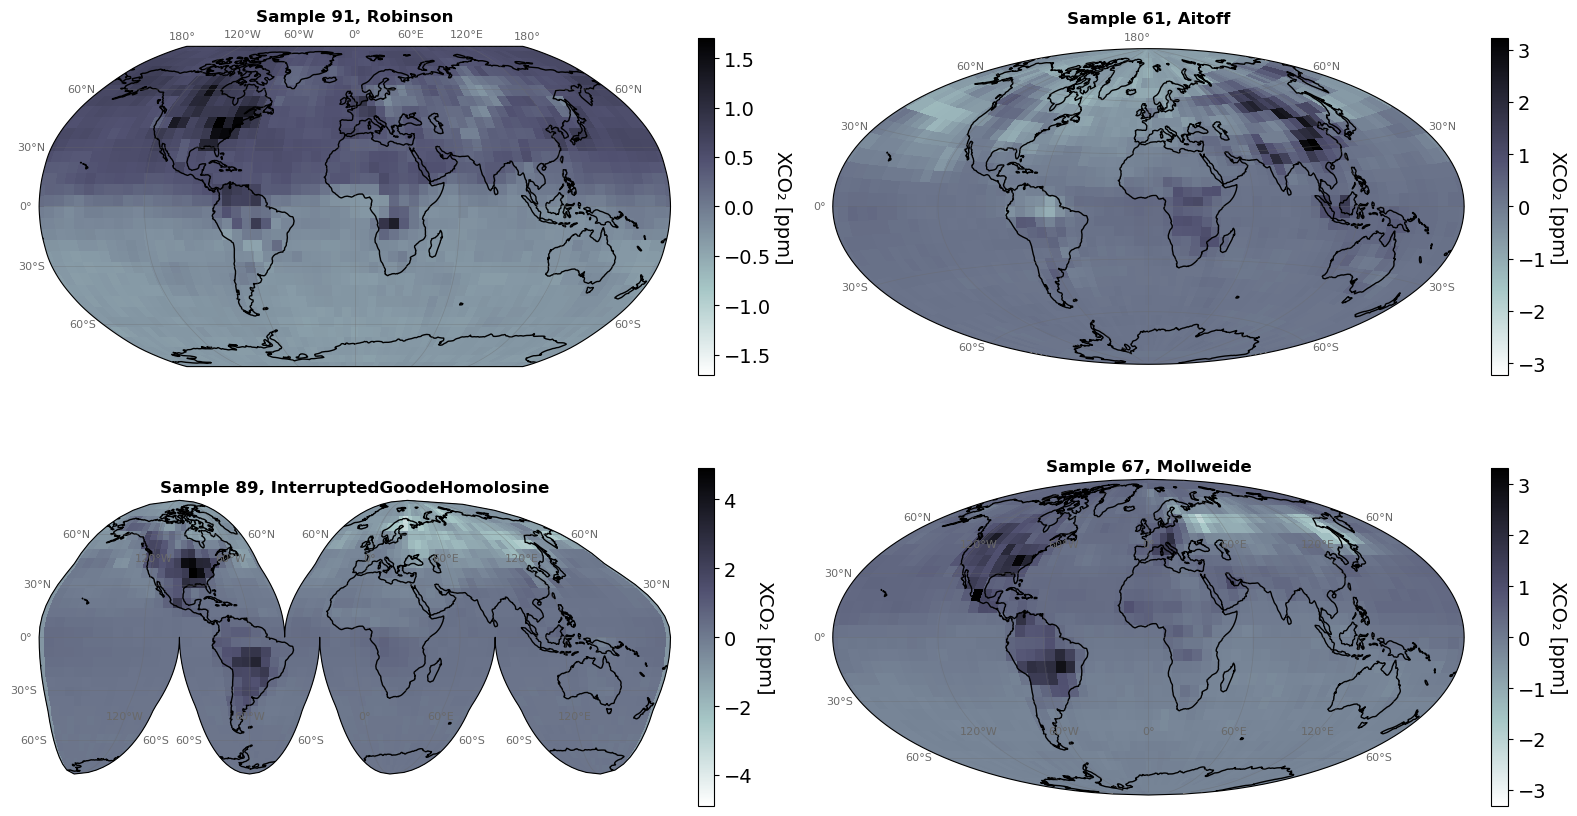

In [61]:
plot_samples_projection(
    samples.trajectory,
    projection=[ccrs.Robinson(), ccrs.Aitoff(), ccrs.InterruptedGoodeHomolosine(), ccrs.Mollweide()],
    terrain=False,
    grid=True,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=4,
    ncol=2,
    sample_indices=None,
    level_idx=0,
    cmaps=["bone_r"]*4,
    seed=7,
    figsize=None,
    show=True,
    savefig=True,
    filename="samples_projection.png",
)

In [62]:
cmap = ["copper_r", "bone_r", "binary", "crest"]


In [63]:
batch_val["co2massmix"].shape

torch.Size([32, 2048, 10])

In [64]:
samples.trajectory.shape

(100, 10, 32, 64, 10)

In [65]:
co2 = batch_val["co2massmix"] # [B=32, N=lat*lon=32*64, C=10]
mean = co2.mean(dim=1)
std = co2.std(dim=1)
co2_normalized = (co2 - mean[:, None]) / std[:, None]

In [66]:
def plot_samples_with_comparison(
    da_traj,
    batch_val,
    projection=None,
    terrain=False,
    grid=False,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=2,
    sample_indices=None,
    level_idx=0,
    cmap="bone_r",
    seed=42,
    figsize=None,
    show=True,
    savefig=False,
    filename="samples_comparison.png",
):
    B, N, C = batch_val.shape
    lat, lon = da_traj.sizes["lat"], da_traj.sizes["lon"]
    if N != lat * lon:
        raise ValueError(f"Expected N={lat*lon}, got N={N}")

    last_time = da_traj.sizes["time"] - 1

    if sample_indices is not None:
        sample_indices = list(sample_indices)[:n_samples]
    else:
        rng = np.random.default_rng(seed)
        sample_indices = list(rng.choice(min(da_traj.sizes["sample"], B),
                                        size=n_samples, replace=False))

    nrow, ncol = n_samples, 2
    aspect = lat / lon
    panel_width = 5.75
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol + 1.5, (panel_height + 0.6) * nrow)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        nrow, ncol,
        figure=fig,
        width_ratios=[1, 1],  # force equal widths
        wspace=0.15, hspace=0.25
    )

    axes = []
    for i in range(n_samples):
        row_axes = []
        for j in range(2):
            ax = fig.add_subplot(
                gs[i, j],
                projection=projection if projection is not None else None
            )
            row_axes.append(ax)
        axes.append(row_axes)

    for i, sample_idx in enumerate(sample_indices):
        ax_pred, ax_true = axes[i]

        da_sample = da_traj.isel(sample=sample_idx, level=level_idx, time=last_time)
        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        gt_field = batch_val[sample_idx, :, level_idx].cpu().numpy().reshape(lat, lon)

        gt_da = xr.DataArray(
            gt_field,
            dims=("lat", "lon"),
            coords={"lat": da_traj["lat"], "lon": da_traj["lon"]},
            name="co2massmix"
        )

        vmin = min(da_sample.min().item(), gt_field.min())
        vmax = max(da_sample.max().item(), gt_field.max())

        # --- Prediction ---
        if projection:
            decorate_earth(ax_pred, terrain=terrain, grid=grid,
                           land=land, ocean=ocean, borders=borders,
                           lakes=lakes, rivers=rivers)
            map_pred = da_sample.plot(
                ax=ax_pred, cmap=cmap, vmin=vmin, vmax=vmax,
                add_colorbar=False, add_labels=False,
                transform=ccrs.PlateCarree()
            )
        else:
            map_pred = da_sample.plot(
                ax=ax_pred, cmap=cmap, vmin=vmin, vmax=vmax,
                add_colorbar=False, add_labels=False
            )
            ax_pred.set_aspect('equal', adjustable='box')

        # ax_pred.set_title(f"Sample {sample_idx} - Prediction", fontsize=11)
        ax_pred.set_xlabel("")
        ax_pred.set_ylabel("")

        # --- Truth ---
        if projection:
            decorate_earth(ax_true, terrain=terrain, grid=grid,
                           land=land, ocean=ocean, borders=borders,
                           lakes=lakes, rivers=rivers)
            map_true = gt_da.plot(
                ax=ax_true, cmap=cmap, vmin=vmin, vmax=vmax,
                add_colorbar=False, add_labels=False,
                transform=ccrs.PlateCarree()
            )
        else:
            map_true = gt_da.plot(
                ax=ax_true, cmap=cmap, vmin=vmin, vmax=vmax,
                add_colorbar=False, add_labels=False
            )
            ax_true.set_aspect("equal", adjustable="box")

        # ax_true.set_title("Ground Truth", fontsize=11)
        ax_true.set_xlabel("")
        ax_true.set_ylabel("")

        # --- Colorbar for this row ---
        cbar_ax = fig.add_axes([
            0.92, ax_pred.get_position().y0,
            0.012, ax_pred.get_position().height
        ])
        fig.colorbar(map_pred, cax=cbar_ax, label="CO₂ (normalized)")

    # fig.subplots_adjust(left=0.05, right=0.90, top=0.88, bottom=0.05)  # leave space for colorbars
    # fig.suptitle(
    #     "Which one is a prediction, which one is ground truth?",
    #     fontsize=16, fontweight="bold",
    #     x=0.5, y=1.05,  # x=0.5 centers horizontally in figure coordinates
    #     ha='center'
    # )
    fig.suptitle("Which one is a generated sample, which one is ground truth?",
                 fontsize=16, fontweight="bold", y=1.05)

    if savefig:
        fig.savefig(filename, dpi=300, bbox_inches="tight")
    if show:
        plt.show()


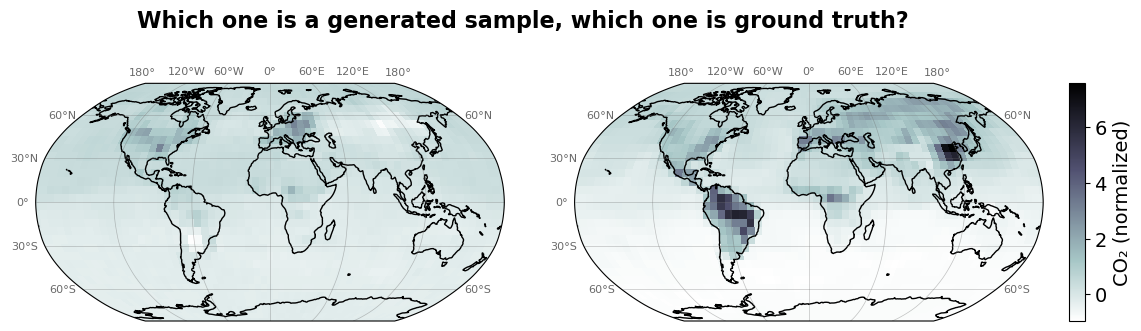

In [67]:
plot_samples_with_comparison(
    samples.trajectory,
    co2_normalized,
    projection=ccrs.Robinson(),
    grid=True,
    n_samples=1,
    sample_indices=None,
    level_idx=0,
    cmap="bone_r",
    seed=9,
    figsize=None,
    show=True,
    savefig=True,
    filename="ground_truth_vs_prediction.png",
)

In [68]:
def plot_samples_with_comparison_bias_hidden(
    da_traj,
    batch_val,
    projection=None,
    terrain=False,
    grid=False,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=2,
    sample_indices=None,
    level_idx=0,
    cmap="bone_r",
    seed=42,
    figsize=None,
    show=True,
    savefig=False,
    filename="samples_comparison.png",
):
    """
    Plot last timestep of selected/random samples side-by-side with reference data.
    Each subplot gets its own color scale and its own colorbar.
    """

    B, N, C = batch_val.shape
    lat, lon = da_traj.sizes["lat"], da_traj.sizes["lon"]
    if N != lat * lon:
        raise ValueError(f"Expected N={lat*lon}, got N={N}")

    last_time = da_traj.sizes["time"] - 1

    # choose sample indices
    if sample_indices is not None:
        sample_indices = list(sample_indices)[:n_samples]
    else:
        rng = np.random.default_rng(seed)
        sample_indices = list(rng.choice(min(da_traj.sizes["sample"], B), size=n_samples, replace=False))

    nrow, ncol = n_samples, 2
    aspect = lat / lon
    panel_width = 5.75
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol, (panel_height + 0.6) * nrow)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        nrow, ncol,
        figure=fig,
        width_ratios=[1, 1],  # force equal widths
        wspace=0.3, hspace=0.25
    )

    axes = []
    for i in range(n_samples):
        row_axes = []
        for j in range(2):
            ax = fig.add_subplot(
                gs[i, j],
                projection=projection if projection is not None else None
            )
            row_axes.append(ax)
        axes.append(row_axes)

    # --- First pass: plotting
    for i, sample_idx in enumerate(sample_indices):
        ax_pred, ax_true = axes[i]

        # --- Prediction data ---
        da_sample = da_traj.isel(sample=sample_idx, level=level_idx, time=last_time)
        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        # --- Ground truth data ---
        gt_field = batch_val[sample_idx, :, level_idx].cpu().numpy().reshape(lat, lon)
        gt_da = xr.DataArray(
            gt_field,
            dims=("lat", "lon"),
            coords={"lat": da_traj["lat"], "lon": da_traj["lon"]},
            name="co2massmix"
        )

        # Prediction subplot
        if projection:
            decorate_earth(ax_pred, terrain=terrain, grid=grid,
                           land=land, ocean=ocean, borders=borders,
                           lakes=lakes, rivers=rivers)
            map_pred = da_sample.plot(
                ax=ax_pred, cmap=cmap,
                add_colorbar=False, add_labels=False,
                transform=ccrs.PlateCarree()
            )
        else:
            map_pred = da_sample.plot(
                ax=ax_pred, cmap=cmap,
                add_colorbar=False, add_labels=False
            )
            ax_pred.set_aspect('equal', adjustable='box')
        ax_pred.set_xlabel("")
        ax_pred.set_ylabel("")

        # Truth subplot
        if projection:
            decorate_earth(ax_true, terrain=terrain, grid=grid,
                           land=land, ocean=ocean, borders=borders,
                           lakes=lakes, rivers=rivers)
            map_true = gt_da.plot(
                ax=ax_true, cmap=cmap,
                add_colorbar=False, add_labels=False,
                transform=ccrs.PlateCarree()
            )
        else:
            map_true = gt_da.plot(
                ax=ax_true, cmap=cmap,
                add_colorbar=False, add_labels=False
            )
            ax_true.set_aspect("equal", adjustable="box")
        ax_true.set_xlabel("")
        ax_true.set_ylabel("")

        # Store mappables on axes for later colorbar creation
        ax_pred._mappable = map_pred
        ax_true._mappable = map_true

    # --- Adjust layout before adding colorbars ---
    fig.subplots_adjust(wspace=0.23, hspace=0.4, left=0.05, right=0.9, top=0.95, bottom=0.05)

    # --- Second pass: add colorbars for each subplot
    for i in range(nrow):
        for j in range(ncol):
            ax = axes[i][j]
            pos = ax.get_position()
            cbar_ax = fig.add_axes([
                pos.x1 + 0.01,  # place slightly to the right of subplot
                pos.y0,
                0.012,          # width
                pos.height
            ])
            fig.colorbar(ax._mappable, cax=cbar_ax, label="XCO₂ [ppm]")

    fig.suptitle("Which one is a prediction, which one is ground truth?",
                 fontsize=16, fontweight="bold")

    if savefig:
        fig.savefig(filename, dpi=300, bbox_inches="tight")
    if show:
        plt.show()


In [69]:
co2 = batch_val["co2massmix"] # [B=32, N=lat*lon=32*64, C=10]
min_val = co2.min(dim=1, keepdim=True).values
max_val = co2.max(dim=1, keepdim=True).values

co2_normalized = (co2 - min_val) / (max_val - min_val)

In [70]:
da_traj = samples.trajectory  # [sample, time, level, lat, lon]

min_val = da_traj.min(dim=("lat", "lon"))
max_val = da_traj.max(dim=("lat", "lon"))

min_val, _ = xr.broadcast(min_val, da_traj)
max_val, _ = xr.broadcast(max_val, da_traj)

da_traj_normalized = (da_traj - min_val) / (max_val - min_val)

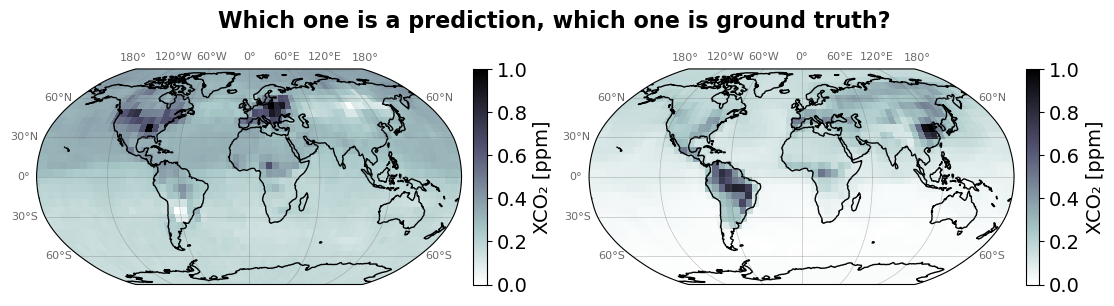

In [71]:
plot_samples_with_comparison_bias_hidden(
    da_traj_normalized,
    co2_normalized,
    projection=ccrs.Robinson(),
    grid=True,
    n_samples=1,
    sample_indices=None,
    level_idx=0,
    cmap="bone_r",
    seed=9,
    figsize=None,
    show=True,
    savefig=True,
    filename="ground_truth_vs_prediction.png",
)

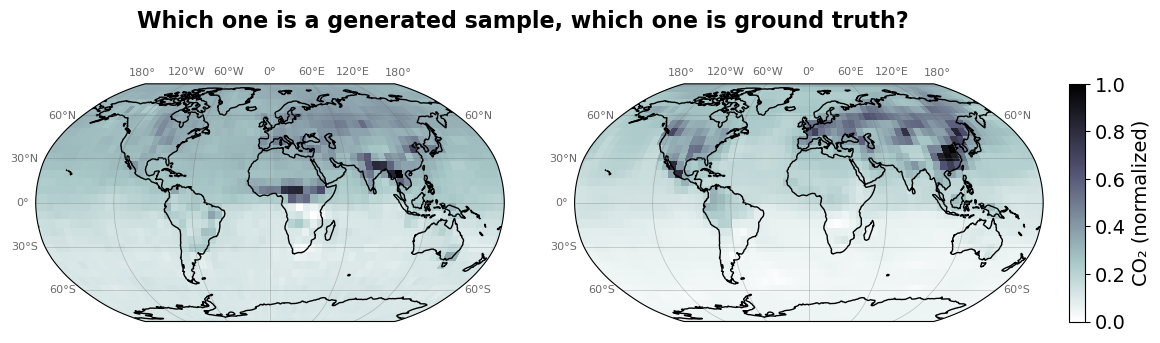

In [80]:
plot_samples_with_comparison(
    da_traj_normalized,
    co2_normalized,
    projection=ccrs.Robinson(),
    grid=True,
    n_samples=1,
    sample_indices=None,
    level_idx=0,
    cmap="bone_r",
    seed=7, # 9 # 3/4/5
    figsize=None,
    show=True,
    savefig=True,
    filename="ground_truth_vs_prediction.png",
)

In [93]:
def plot_samples_projection_one_cbar(
    da_traj,
    projection=None,
    terrain=False,
    grid=False,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=2,
    ncol=2,
    sample_indices=None,
    level_idx=None,
    cmaps=None,
    seed=42,
    figsize=None,
    title=None,
    show=True,
    savefig=False,
    filename="samples.png",
):
    """Plot selected/random samples at the last time step on a global projection."""
    if "sample" not in da_traj.dims:
        raise ValueError("da_traj must have a 'sample' dimension")
    if "time" not in da_traj.dims:
        raise ValueError("da_traj must have a 'time' dimension")
    if "lat" not in da_traj.dims or "lon" not in da_traj.dims:
        raise ValueError("da_traj must have 'lat' and 'lon' dims for plotting")

    # Choose sample indices
    if sample_indices is not None:
        sample_indices = list(sample_indices)[:n_samples]
        if len(sample_indices) < n_samples:
            raise ValueError("sample_indices shorter than n_samples")
    else:
        rng = np.random.default_rng(seed)
        n_available = da_traj.sizes["sample"]
        if n_samples > n_available:
            raise ValueError("n_samples > available samples")
        sample_indices = list(rng.choice(n_available, size=n_samples, replace=False))

    # Setup colormaps
    if cmaps is None:
        cmaps = ["viridis"] * n_samples
    elif len(cmaps) < n_samples:
        cmaps = cmaps + ["viridis"] * (n_samples - len(cmaps))

    # Setup projections
    if projection is None:
        projections = [ccrs.PlateCarree()] * n_samples
    elif isinstance(projection, list):
        if len(projection) < n_samples:
            projections = projection + [projection[-1]] * (n_samples - len(projection))
        else:
            projections = projection[:n_samples]
    else:
        projections = [projection] * n_samples

    # Last time step
    last_time = da_traj.sizes["time"] - 1

    # Grid setup
    nrow = int(np.ceil(n_samples / ncol))
    aspect = da_traj.sizes["lat"] / da_traj.sizes["lon"]
    panel_width = 8.0
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol, (panel_height + 0.6) * nrow)

    # Figure and axes
    fig, axes = plt.subplots(
        nrow, ncol,
        figsize=figsize,
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False
    )
    axes_flat = axes.ravel()

    mapable = None

    for i, (sample_idx, cmap, proj) in enumerate(zip(sample_indices, cmaps, projections)):
        ax = fig.add_subplot(axes_flat[i].get_subplotspec(), projection=proj)
        axes_flat[i].remove()  # remove placeholder
        axes_flat[i] = ax  # replace in flattened list

        da_sample = da_traj.isel(sample=sample_idx, time=last_time)

        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        if level_idx is None:
            da_sample = da_sample.mean(dim="level")
            label_title = "XCO₂ (normalized)"
        else:
            da_sample = da_sample.isel(level=level_idx)
            label_title = "CO₂ (normalized)"

        decorate_earth(
            ax,
            terrain=terrain,
            grid=grid,
            land=land, ocean=ocean, borders=borders, lakes=lakes, rivers=rivers
        )
        mapable = da_sample.plot(
            ax=ax, cmap=cmap, add_colorbar=False, add_labels=False,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(f"Sample {sample_idx}", fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Hide unused axes (if n_samples not multiple of ncol)
    for j in range(len(sample_indices), len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared colorbar at the bottom
    cbar = fig.colorbar(
        mapable, ax=axes.ravel().tolist(), orientation="horizontal",
        fraction=0.03, pad=0.06)
    cbar.ax.set_xlabel(label_title, labelpad=10, fontsize=12)

    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold")

    if savefig:
        fig.savefig(filename, dpi=300)
    if show:
        plt.show()

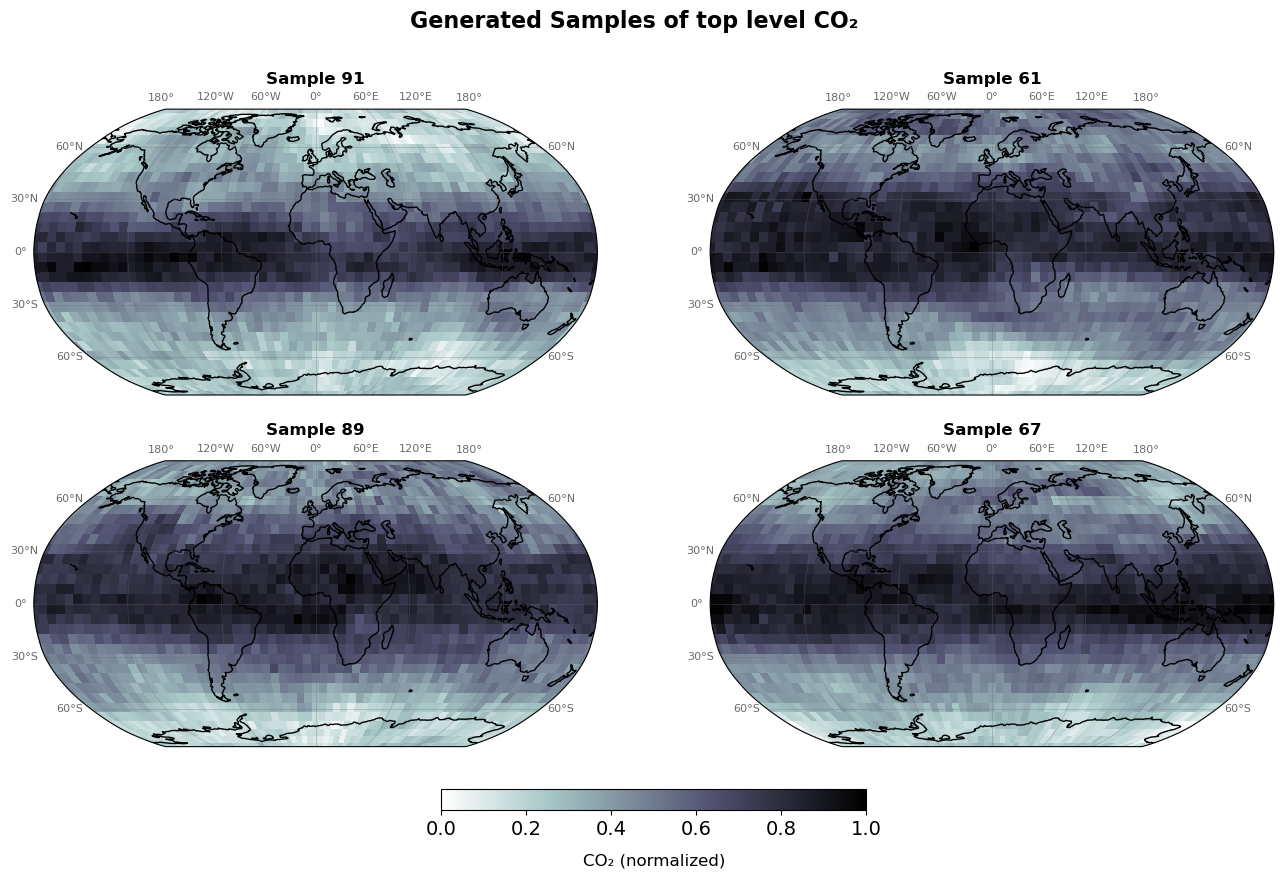

In [ ]:
plot_samples_projection_one_cbar(
    da_traj_normalized,
    projection=[ccrs.Robinson()]*4,
    terrain=False,
    grid=True,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=4,
    level_idx=0,
    ncol=2,
    sample_indices=None,
    cmaps=["bone_r"]*4,
    seed=7,
    figsize=None,
    title="Generated Samples of top level CO₂",
    show=True,
    savefig=True,
    filename="samples_Robinson.png",
)

In [116]:
def plot_samples_and_ground_truth(
    da_traj,
    batch_val,
    projection=None,
    terrain=False, grid=False,
    land=False, ocean=False, borders=False, lakes=False, rivers=False,
    n_samples=2,
    sample_indices=None,
    level_idx=None,
    cmap="bone_r",
    seed=42,
    figsize=None,
    show=True,
    savefig=False,
    filename="samples_comparison.png",
):

    B, N, C = batch_val.shape
    lat, lon = da_traj.sizes["lat"], da_traj.sizes["lon"]
    if N != lat * lon:
        raise ValueError(f"Expected N={lat*lon}, got N={N}")

    last_time = da_traj.sizes["time"] - 1

    # Sample selection
    if sample_indices is not None:
        sample_indices = list(sample_indices)[:n_samples]
    else:
        rng = np.random.default_rng(seed)
        sample_indices = list(rng.choice(min(da_traj.sizes["sample"], B),
                                        size=n_samples, replace=False))

    # Figure setup
    nrow, ncol = n_samples, 2
    aspect = lat / lon
    panel_width = 5.75
    panel_height = panel_width * aspect
    if figsize is None:
        figsize = (panel_width * ncol + 1.5, (panel_height + 0.6) * nrow)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        nrow, ncol,
        figure=fig,
        width_ratios=[1, 1],
        wspace=0.15, hspace=0.25
    )

    axes = []
    for i in range(n_samples):
        row_axes = []
        for j in range(2):
            ax = fig.add_subplot(
                gs[i, j],
                projection=projection if projection is not None else None
            )
            row_axes.append(ax)
        axes.append(row_axes)

    # Keep track of last plotted map for colorbar
    mapable = None

    for i, sample_idx in enumerate(sample_indices):
        ax_pred, ax_true = axes[i]

        # Select sample
        da_sample = da_traj.isel(sample=sample_idx, time=last_time)
        with contextlib.suppress(Exception):
            da_sample = da_sample.compute()

        if level_idx is None:
            da_sample = da_sample.mean(dim="level")
            label_bar = "XCO₂ (normalized)"
        else:
            da_sample = da_sample.isel(level=level_idx)
            label_bar = "CO₂ (normalized)"

        # Ground truth
        if level_idx is None:
            gt_field = batch_val[sample_idx, :, :].mean(axis=1).cpu().numpy().reshape(lat, lon)
        else:
            gt_field = batch_val[sample_idx, :, level_idx].cpu().numpy().reshape(lat, lon)
        gt_da = xr.DataArray(
            gt_field,
            dims=("lat", "lon"),
            coords={"lat": da_traj["lat"], "lon": da_traj["lon"]},
            name="co2massmix"
        )

        # --- Prediction ---
        if projection:
            decorate_earth(ax_pred, terrain=terrain, grid=grid,
                           land=land, ocean=ocean, borders=borders,
                           lakes=lakes, rivers=rivers)
            map_pred = da_sample.plot(
                ax=ax_pred, cmap=cmap, add_colorbar=False, add_labels=False,
                transform=ccrs.PlateCarree()
            )
        else:
            map_pred = da_sample.plot(
                ax=ax_pred, cmap=cmap, add_colorbar=False, add_labels=False
            )
            ax_pred.set_aspect("equal", adjustable="box")
        ax_pred.set_title(f"Sample {sample_idx}", fontsize=11)
        ax_pred.set_xlabel("")
        ax_pred.set_ylabel("")

        # --- Ground Truth ---
        if projection:
            decorate_earth(ax_true, terrain=terrain, grid=grid,
                           land=land, ocean=ocean, borders=borders,
                           lakes=lakes, rivers=rivers)
            map_true = gt_da.plot(
                ax=ax_true, cmap=cmap, add_colorbar=False, add_labels=False,
                transform=ccrs.PlateCarree()
            )
        else:
            map_true = gt_da.plot(
                ax=ax_true, cmap=cmap, add_colorbar=False, add_labels=False
            )
            ax_true.set_aspect("equal", adjustable="box")
        ax_true.set_xlabel("")
        ax_true.set_ylabel("")

        # Keep last map for shared colorbar
        mapable = map_pred

    # Add top titles for columns
    axes[0][0].text(0.5, 1.25, "Prediction", fontsize=13, fontweight="bold", ha="center", transform=axes[0][0].transAxes)
    axes[0][1].text(0.5, 1.25, "Ground Truth", fontsize=13, fontweight="bold", ha="center", transform=axes[0][1].transAxes)

    # Single horizontal colorbar
    cbar = fig.colorbar(
        mapable,
        ax=[ax for row in axes for ax in row],
        orientation="horizontal",
        fraction=0.04,
        pad=0.08,
        aspect=25
    )
    cbar.ax.set_xlabel(label_bar, labelpad=10, fontsize=12)

    fig.suptitle("Generated Samples vs. Ground Truth",
                 fontsize=16, fontweight="bold", y=1.05)

    if savefig:
        fig.savefig(filename, dpi=300, bbox_inches="tight")
    if show:
        plt.show()


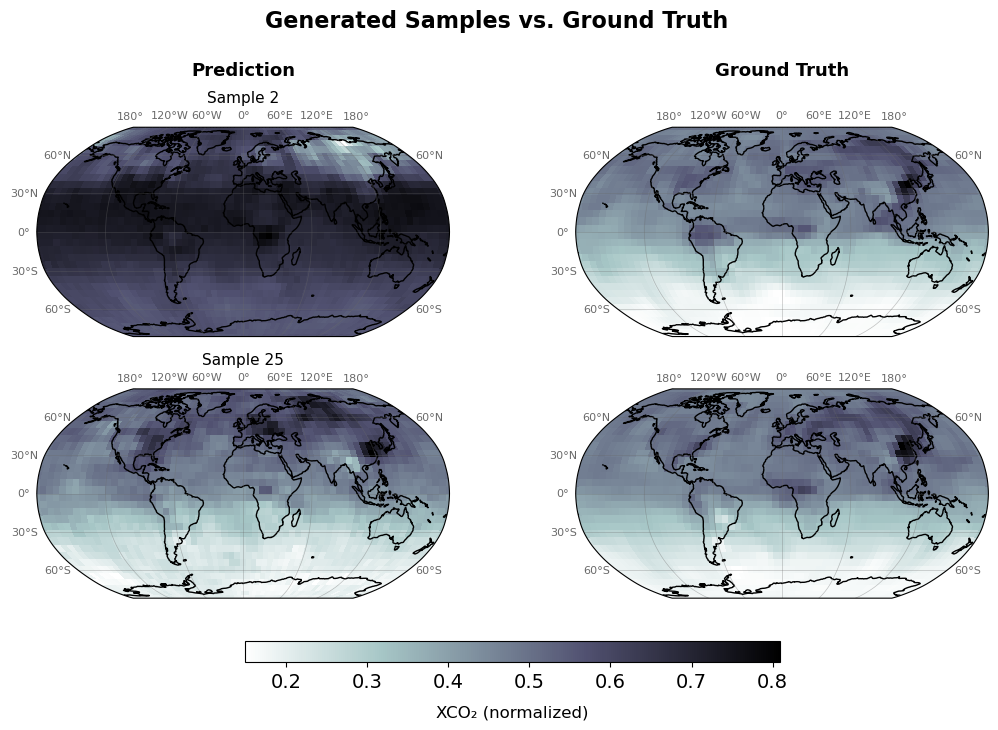

In [117]:
plot_samples_and_ground_truth(
    da_traj_normalized,
    co2_normalized,
    projection=ccrs.Robinson(),
    grid=True,
    n_samples=2,
    sample_indices=None,
    cmap="bone_r",
    seed=3, # 9 # 3/4/5
    figsize=None,
    show=True,
    savefig=True,
    filename="ground_truth_vs_prediction.png",
)

In [193]:
def plot_trajectory_timeseries(
    trajectory: xr.DataArray,
    sample_idx: int = 0,
    level_idx: int | None = 0,
    projection=None,
    cmap="bone_r",
    figsize=None,
    show=True,
    savefig=False,
    filename="trajectory_timeseries.png",
):
    da_sample = trajectory.isel(sample=sample_idx)

    if level_idx is None:
        da_sample = da_sample.mean(dim="level")
        label_bar = "XCO₂ (normalized)"
    else:
        da_sample = da_sample.isel(level=level_idx)
        label_bar = "CO₂ (normalized)"

    nsteps = da_sample.sizes["time"]
    lat, lon = da_sample.sizes["lat"], da_sample.sizes["lon"]

    ncols = nsteps // 2 if nsteps % 2 == 0 else (nsteps + 1) // 2
    nrows = 2 if nsteps > ncols else 1

    if figsize is None:
        panel_width = 3
        panel_height = panel_width * lat / lon
        figsize = (panel_width * ncols, panel_height * nrows)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.05, hspace=0.15)  # less space

    # Determine global min/max
    data_to_plot = da_sample.values
    if data_to_plot.ndim == 3:
        data_to_plot = data_to_plot if level_idx is not None else data_to_plot.mean(axis=-1)
    vmin, vmax = np.nanmin(data_to_plot), np.nanmax(data_to_plot)

    axes = []
    for i in range(nsteps):
        row = i // ncols
        col = i % ncols
        ax = fig.add_subplot(gs[row, col], projection=projection if projection else None)
        axes.append(ax)

        map_data = da_sample.isel(time=i).values

        if projection is None:
            im = ax.imshow(map_data, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_aspect("equal", adjustable="box")
        else:
            im = ax.pcolormesh(
                da_sample["lon"], da_sample["lat"],
                map_data, cmap=cmap, transform=ccrs.PlateCarree()
            )
            # ax.coastlines()
            # ax.set_global()

        # Remove axes ticks/spines
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.text(
            0.05, 0.95, f"t={i}",
            transform=ax.transAxes,
            fontsize=12, fontweight="bold",
            color="white",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )

    # Hide unused subplots
    for i in range(nsteps, nrows * ncols):
        axes[i].set_visible(False)

    # Horizontal colorbar below
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.05])  # slightly lower
    fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar_ax.set_xlabel(label_bar, fontsize=12, labelpad=10)

    if savefig:
        fig.savefig(filename, dpi=300, bbox_inches="tight")
    if show:
        plt.show()


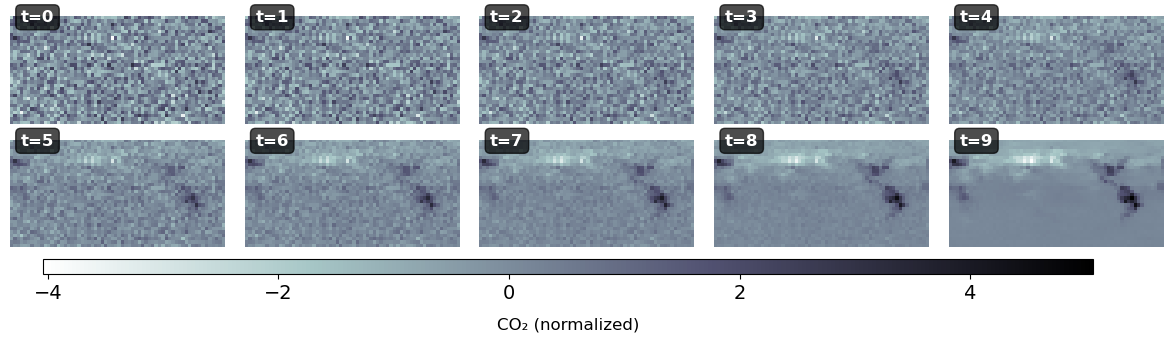

In [195]:
plot_trajectory_timeseries(
    samples.trajectory,
    sample_idx=7,
    level_idx=0,
    projection=None,
    cmap="bone_r",
    figsize=None,
    show=True,
    savefig=True,
    filename="trajectory_timeseries.png",
)